# VIRTUOSO Pipeline
## VIRTual Unified Operation Security Optimiser

**Changes v8 -> v9:** Per-fold tracking (mean +/- std), Friedman + Nemenyi tests, DNN repeated splits, timing, FPR/FNR, portability, paper-ready export.

## Cell 1 -- Environment Setup

In [1]:
# Cell 1 - Environment / path setup (fully portable, auto-download)
import os, sys, time, random, warnings, subprocess, tarfile, shutil
from pathlib import Path
import numpy as np

warnings.filterwarnings('ignore', category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

WORK_DIR = Path('/content/virtuoso') if IN_COLAB else Path(os.environ.get('VIRTUOSO_BASE', os.getcwd())) / 'virtuoso'
WORK_DIR.mkdir(parents=True, exist_ok=True)
os.chdir(WORK_DIR)

DATA_DIR = WORK_DIR / 'data'
DATA_DIR.mkdir(exist_ok=True)

print(f'[Info] SEED={SEED}, IN_COLAB={IN_COLAB}')
print(f'[Path] WORK_DIR: {WORK_DIR}')

# ============================================================
# AUTO-DOWNLOAD DATASETS
# ============================================================
import urllib.request

def download_file(url, dest, desc=''):
    if dest.exists():
        print(f'  [SKIP] {desc or dest.name} already exists')
        return
    print(f'  [DOWNLOAD] {desc or dest.name}...')
    urllib.request.urlretrieve(url, str(dest))
    print(f'  [OK] {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)')

def ensure_aws_cli():
    try:
        subprocess.run(['aws', '--version'], check=True, capture_output=True)
    except FileNotFoundError:
        print('  [INFO] Installing aws CLI...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'awscli'], check=True)

# --- 1. UNSW-NB15 ---
UNSW_TRAIN_PATH = DATA_DIR / 'UNSW_NB15_training-set.csv'
UNSW_TEST_PATH  = DATA_DIR / 'UNSW_NB15_testing-set.csv'

print('\n[1/3] UNSW-NB15 dataset:')
if UNSW_TRAIN_PATH.exists() and UNSW_TEST_PATH.exists():
    print('  [SKIP] Already downloaded')
else:
    try:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kagglehub'], check=True)
        import kagglehub
        kpath = kagglehub.dataset_download('mrwellsdavid/unsw-nb15')
        print(f'  [OK] Via kagglehub: {kpath}')
        for f in Path(kpath).rglob('*.csv'):
            fn = f.name.lower()
            if 'training' in fn and not UNSW_TRAIN_PATH.exists():
                shutil.copy(f, UNSW_TRAIN_PATH)
                print(f'  Copied {f.name} -> {UNSW_TRAIN_PATH.name}')
            elif 'testing' in fn and not UNSW_TEST_PATH.exists():
                shutil.copy(f, UNSW_TEST_PATH)
                print(f'  Copied {f.name} -> {UNSW_TEST_PATH.name}')
    except Exception as e:
        print(f'  [ERROR] {e}')
        print(f'  Please place UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv in {DATA_DIR}')

# --- 2. CSE-CIC-IDS2018 (web attack days: Thursday-22 + Friday-23) ---
CSE_DIR = DATA_DIR / 'CSE-CIC-IDS2018'
CSE_DIR.mkdir(exist_ok=True)
S3_BASE = 's3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/'

CSE_WEB_DAY_FILES = [
    'Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv',
    'Friday-23-02-2018_TrafficForML_CICFlowMeter.csv',
]

print('\n[2/3] CSE-CIC-IDS2018 web attack files:')
need_download = [f for f in CSE_WEB_DAY_FILES if not (CSE_DIR / f).exists()]
if need_download:
    ensure_aws_cli()
    for fname in need_download:
        dest = CSE_DIR / fname
        print(f'  Downloading {fname} (~300 MB)...')
        try:
            subprocess.run([
                'aws', 's3', 'cp', '--no-sign-request', '--region', 'us-east-1',
                f'{S3_BASE}{fname}', str(dest)
            ], check=True, capture_output=True, timeout=600)
            print(f'  [OK] {fname} ({dest.stat().st_size / 1e6:.1f} MB)')
        except Exception as e:
            print(f'  [WARN] {e}')
else:
    print('  [SKIP] All web attack files present')

# --- 3. CloudTrail flAWS logs ---
CT_DIR = DATA_DIR / 'cloudtrail'
CT_DIR.mkdir(exist_ok=True)
CT_TAR = DATA_DIR / 'flaws_cloudtrail_logs.tar'
CT_URL = 'http://summitroute.com/downloads/flaws_cloudtrail_logs.tar'

print('\n[3/3] CloudTrail flAWS logs:')
ct_jsons = list(CT_DIR.rglob('*.json')) + list(CT_DIR.rglob('*.json.gz'))
if len(ct_jsons) > 0:
    print(f'  [SKIP] {len(ct_jsons)} JSON files already present')
else:
    try:
        download_file(CT_URL, CT_TAR, 'flAWS CloudTrail tar')
        print('  Extracting...')
        with tarfile.open(CT_TAR) as tar:
            tar.extractall(CT_DIR, filter='data')
        ct_jsons = list(CT_DIR.rglob('*.json')) + list(CT_DIR.rglob('*.json.gz'))
        print(f'  [OK] Extracted {len(ct_jsons)} log files')
    except Exception as e:
        print(f'  [WARN] {e}')

# --- Summary ---
print('\n[Check] Dataset files:')
for label, p in [('UNSW train', UNSW_TRAIN_PATH), ('UNSW test', UNSW_TEST_PATH)]:
    print(f'  [{"OK" if p.exists() else "MISSING"}] {label}: {p}')
for fname in CSE_WEB_DAY_FILES:
    p = CSE_DIR / fname
    print(f'  [{"OK" if p.exists() else "MISSING"}] CSE {fname}')
n_ct = len(list(CT_DIR.rglob('*.json*')))
print(f'  [{"OK" if n_ct > 0 else "EMPTY"}] CloudTrail: {n_ct} files in {CT_DIR}')

[Info] SEED=42, IN_COLAB=True
[Path] WORK_DIR: /content/virtuoso

[1/3] UNSW-NB15 dataset:
Using Colab cache for faster access to the 'unsw-nb15' dataset.
  [OK] Via kagglehub: /kaggle/input/unsw-nb15
  Copied UNSW_NB15_testing-set.csv -> UNSW_NB15_testing-set.csv
  Copied UNSW_NB15_training-set.csv -> UNSW_NB15_training-set.csv

[2/3] CSE-CIC-IDS2018 web attack files:
  [INFO] Installing aws CLI...
  [OK] Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv (382.6 MB)
  [OK] Friday-23-02-2018_TrafficForML_CICFlowMeter.csv (382.8 MB)

[3/3] CloudTrail flAWS logs:
  [DOWNLOAD] flAWS CloudTrail tar...
  [OK] flaws_cloudtrail_logs.tar (251.7 MB)
  Extracting...
  [OK] Extracted 20 log files

[Check] Dataset files:
  [OK] UNSW train: /content/virtuoso/data/UNSW_NB15_training-set.csv
  [OK] UNSW test: /content/virtuoso/data/UNSW_NB15_testing-set.csv
  [OK] CSE Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
  [OK] CSE Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
  [OK] CloudTrail: 20 file

## Cell 3 -- Shared Utilities

In [2]:
# Cell 3 - Shared utilities
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
)

def time_run(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    elapsed = time.perf_counter() - start
    return result, elapsed

def compute_binary_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'mcc':       matthews_corrcoef(y_true, y_pred),
        'auc_roc':   roc_auc_score(y_true, y_score),
        'auc_pr':    average_precision_score(y_true, y_score),
    }

def plot_roc_pr_curves(y_true, y_score, title_prefix=''):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    if len(np.unique(y_true)) < 2:
        print('[WARN] Cannot plot ROC/PR: only one class.')
        return
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc_val = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    pr_auc_val = auc(rec, prec)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_val:.4f}')
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
    plt.xlabel('FPR'); plt.ylabel('TPR')
    plt.title(f'{title_prefix} ROC'); plt.legend(); plt.grid(True)
    plt.subplot(1, 2, 2)
    plt.plot(rec, prec, label=f'AUC = {pr_auc_val:.4f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'{title_prefix} PR'); plt.legend(); plt.grid(True)
    plt.tight_layout(); plt.show()

## Cell 4 -- Channel 1 / UNSW-NB15 Preprocessing

In [3]:
# Cell 4 - UNSW-NB15 preprocessing (from training + testing CSVs)
import pandas as pd

UNSW_TRAIN_PATH = DATA_DIR / 'UNSW_NB15_training-set.csv'
UNSW_TEST_PATH  = DATA_DIR / 'UNSW_NB15_testing-set.csv'
UNSW_X_PATH = DATA_DIR / 'UNSW_X.csv'
UNSW_y_PATH = DATA_DIR / 'UNSW_y.csv'

if not UNSW_TRAIN_PATH.exists():
    raise FileNotFoundError(f'UNSW training set not found at {UNSW_TRAIN_PATH}')

print('[UNSW] Loading training + testing sets...')
df_train = pd.read_csv(UNSW_TRAIN_PATH, low_memory=False)
df_test  = pd.read_csv(UNSW_TEST_PATH, low_memory=False)
df_unsw  = pd.concat([df_train, df_test], ignore_index=True)
print(f'[UNSW] Combined shape: {df_unsw.shape}')

# Standardize column names (strip whitespace)
df_unsw.columns = df_unsw.columns.str.strip()

# Keep only label column, drop multiclass attack_cat and id
for col in ['attack_cat', 'id']:
    if col in df_unsw.columns:
        df_unsw.drop(columns=[col], inplace=True)

if 'label' not in df_unsw.columns:
    raise KeyError(f"'label' not found. Available: {df_unsw.columns.tolist()}")

X_unsw = df_unsw.drop(columns=['label'])
y_unsw = df_unsw['label'].astype(int)
X_unsw.to_csv(UNSW_X_PATH, index=False)
y_unsw.to_csv(UNSW_y_PATH, index=False)
print(f'[UNSW] X: {X_unsw.shape}, y: {y_unsw.shape}')
print(f'[UNSW] Classes:\n{y_unsw.value_counts()}')


[UNSW] Loading training + testing sets...
[UNSW] Combined shape: (257673, 45)
[UNSW] X: (257673, 42), y: (257673,)
[UNSW] Classes:
label
1    164673
0     93000
Name: count, dtype: int64


## Cell 5 -- Channel 1 / CSE-CIC-IDS2018 WEB Subset

In [4]:
# Cell 5 - CSE-CIC-IDS2018 WEB subset (Thursday-22 + Friday-23)
# Includes feature cleaning: remove zero-variance, deduplicate highly correlated

IDS_X_WEB_PATH = DATA_DIR / 'IDS_X_web.csv'
IDS_y_WEB_PATH = DATA_DIR / 'IDS_y_web.csv'

CSE_DIR = DATA_DIR / 'CSE-CIC-IDS2018'
cse_web_csvs = [
    CSE_DIR / 'Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv',
    CSE_DIR / 'Friday-23-02-2018_TrafficForML_CICFlowMeter.csv',
]

missing = [f for f in cse_web_csvs if not f.exists()]
if missing:
    raise FileNotFoundError(f'Missing CSE files: {missing}')

print('[CSE] Loading web-attack day files...')
frames = []
for fp in cse_web_csvs:
    print(f'  Loading {fp.name}...')
    df = pd.read_csv(fp, low_memory=False)
    df.columns = df.columns.str.strip()
    frames.append(df)
    print(f'    Shape: {df.shape}, Labels: {df["Label"].value_counts().to_dict()}')

df_all = pd.concat(frames, ignore_index=True)
print(f'[CSE] Combined shape: {df_all.shape}')
print(f'[CSE] All labels:\n{df_all["Label"].value_counts()}')

# Web attack labels
web_labels = ['Brute Force -Web', 'Brute Force -XSS', 'SQL Injection']
attack_mask = df_all['Label'].isin(web_labels)
benign_mask = df_all['Label'] == 'Benign'

df_attack = df_all.loc[attack_mask].copy()
df_benign = df_all.loc[benign_mask].copy()
print(f'[WEB] Attack rows: {len(df_attack)}, Benign rows: {len(df_benign)}')

if len(df_attack) == 0:
    print('[WARN] No web attack rows found!')
    print(df_all['Label'].unique())
    raise ValueError('No web attack labels matched.')

X_attack = df_attack.select_dtypes(include='number')
X_benign = df_benign.select_dtypes(include='number')

common_cols = X_attack.columns.intersection(X_benign.columns)
min_samples = min(len(X_attack), len(X_benign))
print(f'[WEB] Balancing to {min_samples} per class, {len(common_cols)} raw features')

X_attack_bal = X_attack[common_cols].sample(n=min_samples, random_state=SEED)
X_benign_bal = X_benign[common_cols].sample(n=min_samples, random_state=SEED)
y_attack_bal = pd.Series(1, index=X_attack_bal.index)
y_benign_bal = pd.Series(0, index=X_benign_bal.index)

X_web = pd.concat([X_benign_bal, X_attack_bal]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
y_web = pd.concat([y_benign_bal, y_attack_bal]).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

# Clean inf/nan
X_web = X_web.replace([np.inf, -np.inf], np.nan).fillna(0)

# ============================================================
# FEATURE SELECTION: reduce dimensionality for small dataset
# ============================================================
print(f'\n[Feature Selection] Starting with {X_web.shape[1]} features...')

# Step 1: Remove zero/near-zero variance features
from sklearn.feature_selection import VarianceThreshold
var_thresh = VarianceThreshold(threshold=1e-6)
X_web_var = pd.DataFrame(
    var_thresh.fit_transform(X_web),
    columns=X_web.columns[var_thresh.get_support()]
)
n_removed_var = X_web.shape[1] - X_web_var.shape[1]
print(f'  [Step 1] Removed {n_removed_var} zero/near-zero variance features -> {X_web_var.shape[1]} remain')

# Step 2: Remove highly correlated features (|r| > 0.95)
corr_matrix = X_web_var.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
X_web_clean = X_web_var.drop(columns=to_drop_corr)
print(f'  [Step 2] Removed {len(to_drop_corr)} highly correlated features (|r|>0.95) -> {X_web_clean.shape[1]} remain')

# Step 3: Report final feature/sample ratio
ratio = len(X_web_clean) / X_web_clean.shape[1]
print(f'  [Final] {X_web_clean.shape[1]} features, {len(X_web_clean)} samples, ratio={ratio:.1f} samples/feature')

X_web = X_web_clean

X_web.to_csv(IDS_X_WEB_PATH, index=False)
y_web.to_csv(IDS_y_WEB_PATH, index=False)
print(f'\n[WEB] Final: X={X_web.shape}, y={y_web.shape}')
print(f'[WEB] Class balance: {y_web.value_counts().to_dict()}')

[CSE] Loading web-attack day files...
  Loading Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv...
    Shape: (1048575, 80), Labels: {'Benign': 1048213, 'Brute Force -Web': 249, 'Brute Force -XSS': 79, 'SQL Injection': 34}
  Loading Friday-23-02-2018_TrafficForML_CICFlowMeter.csv...
    Shape: (1048575, 80), Labels: {'Benign': 1048009, 'Brute Force -Web': 362, 'Brute Force -XSS': 151, 'SQL Injection': 53}
[CSE] Combined shape: (2097150, 80)
[CSE] All labels:
Label
Benign              2096222
Brute Force -Web        611
Brute Force -XSS        230
SQL Injection            87
Name: count, dtype: int64
[WEB] Attack rows: 928, Benign rows: 2096222
[WEB] Balancing to 928 per class, 78 raw features

[Feature Selection] Starting with 78 features...
  [Step 1] Removed 10 zero/near-zero variance features -> 68 remain
  [Step 2] Removed 30 highly correlated features (|r|>0.95) -> 38 remain
  [Final] 38 features, 1856 samples, ratio=48.8 samples/feature

[WEB] Final: X=(1856, 38), y=(1856,)
[WE

## Cell 7 -- DNN Architecture

In [5]:
# Cell 7 - DNN model definition
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
# Use specific imports to avoid name shadowing
from tensorflow.keras import layers

def build_dnn(input_dim, n_hidden=[128, 64], dropout_rate=0.2):
    # Use tf.keras.Sequential directly to avoid conflict with the 'models' variable
    model = tf.keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in n_hidden:
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

print('DNN builder ready with robust naming.')

DNN builder ready with robust naming.


## Cell 8 -- DNN Training with Repeated Splits (v9)
*Reports mean +/- std across N repeats with different random seeds.*

[UNSW] Training DNN...
  Repeat 1/5 - acc= 0.9332, f1= 0.9466, auc= 0.9872, train= 30.9s
  Repeat 2/5 - acc= 0.9310, f1= 0.9445, auc= 0.9871, train= 27.5s
  Repeat 3/5 - acc= 0.9282, f1= 0.9423, auc= 0.9868, train= 27.3s
  Repeat 4/5 - acc= 0.9303, f1= 0.9439, auc= 0.9865, train= 27.5s
  Repeat 5/5 - acc= 0.9292, f1= 0.9429, auc= 0.9870, train= 27.2s

[UNSW-NB15] DNN summary (5 repeats):
  accuracy:  0.9304 +/-  0.0019
  precision:  0.9706 +/-  0.0022
  recall:  0.9189 +/-  0.0047
  f1:  0.9440 +/-  0.0017
  mcc:  0.8543 +/-  0.0033
  auc_roc:  0.9869 +/-  0.0003
  fpr:  0.0494 +/-  0.0041
  fnr:  0.0811 +/-  0.0047

[WEB] Training DNN...
  Repeat 1/5 - acc= 0.9543, f1= 0.9561, auc= 0.9925, train= 7.4s


  Repeat 2/5 - acc= 0.9651, f1= 0.9661, auc= 0.9958, train= 6.0s
  Repeat 3/5 - acc= 0.9570, f1= 0.9585, auc= 0.9940, train= 6.0s
  Repeat 4/5 - acc= 0.9489, f1= 0.9514, auc= 0.9954, train= 6.0s
  Repeat 5/5 - acc= 0.9435, f1= 0.9460, auc= 0.9909, train= 6.3s

[CSE-CIC-IDS2018-WEB] DNN summary (5 repeats):
  accuracy:  0.9538 +/-  0.0082
  precision:  0.9196 +/-  0.0136
  recall:  0.9946 +/-  0.0038
  f1:  0.9556 +/-  0.0075
  mcc:  0.9107 +/-  0.0153
  auc_roc:  0.9937 +/-  0.0020
  fpr:  0.0871 +/-  0.0159
  fnr:  0.0054 +/-  0.0038


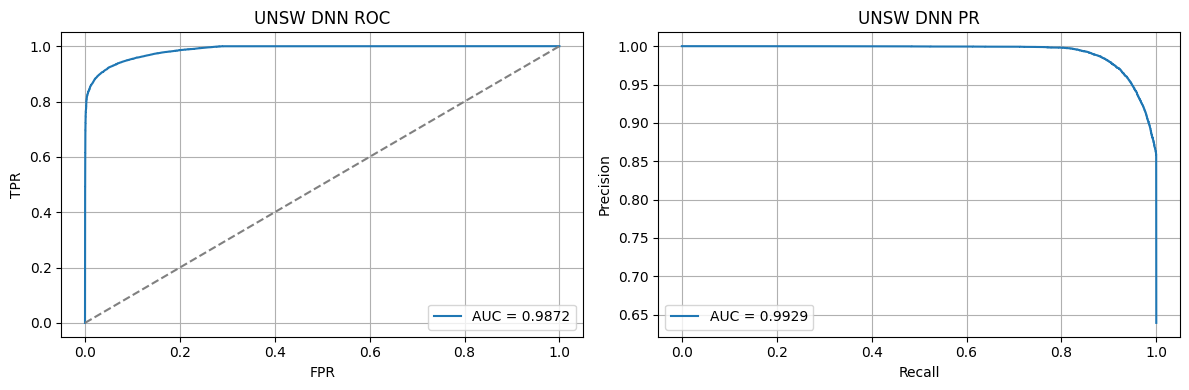

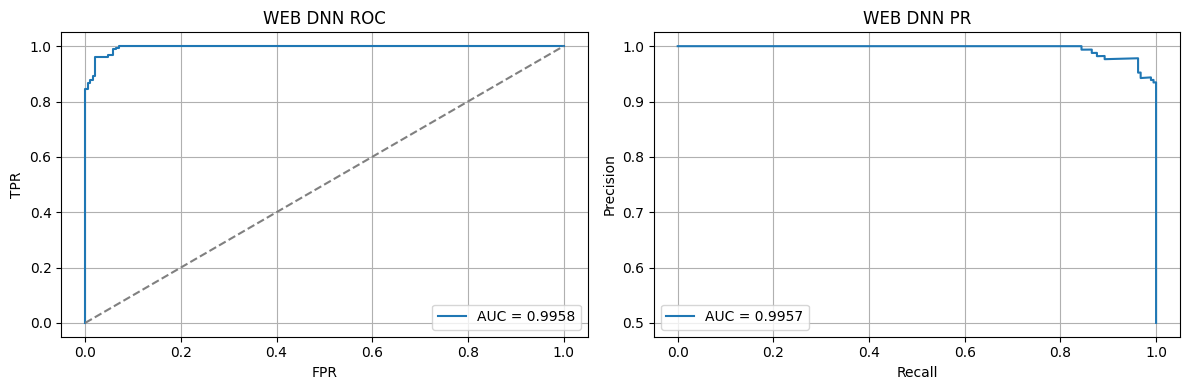

In [6]:
# Cell 8 - DNN with repeated stratified splits
N_DNN_REPEATS = 5

def train_dnn_repeated(X, y, dataset_name, n_repeats=N_DNN_REPEATS,
                       test_size=0.2, epochs=15, batch_size=256):
    if X.empty or len(y) == 0:
        print(f'[SKIP] {dataset_name} has no data.')
        return None, None, None, None, None, pd.DataFrame()

    X = np.asarray(X, dtype='float32')
    y = np.asarray(y, dtype='float32')
    all_metrics = []
    best_model, best_auc = None, -1

    for i in range(n_repeats):
        seed_i = SEED + i
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=seed_i)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        n_pos = y_train.sum(); n_neg = len(y_train) - n_pos
        class_w = {0: 1.0, 1: n_neg / (n_pos + 1e-8)}

        tf.random.set_seed(seed_i)
        model = build_dnn(input_dim=X_train_s.shape[1])
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss='binary_crossentropy', metrics=['accuracy'])

        t0 = time.perf_counter()
        model.fit(X_train_s, y_train, validation_split=0.1,
                  batch_size=batch_size, epochs=epochs, verbose=0,
                  class_weight=class_w,
                  callbacks=[
                      tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss'),
                      tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2, monitor='val_loss'),
                  ])
        train_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        y_scores = model.predict(X_test_s, batch_size=batch_size, verbose=0).ravel()
        infer_time = time.perf_counter() - t0

        m = compute_binary_metrics(y_test, y_scores, threshold=0.5)
        y_pred = (y_scores >= 0.5).astype(int); y_ti = y_test.astype(int)
        tn=((y_pred==0)&(y_ti==0)).sum(); fp=((y_pred==1)&(y_ti==0)).sum()
        fn=((y_pred==0)&(y_ti==1)).sum(); tp=((y_pred==1)&(y_ti==1)).sum()
        m['fpr'] = fp/(fp+tn) if (fp+tn)>0 else 0.0
        m['fnr'] = fn/(fn+tp) if (fn+tp)>0 else 0.0
        m['train_time_s'] = train_time; m['infer_time_s'] = infer_time
        m['repeat'] = i
        all_metrics.append(m)

        if m['auc_roc'] > best_auc:
            best_auc = m['auc_roc']
            best_model, best_scaler = model, scaler
            best_X_test_s, best_y_test, best_y_scores = X_test_s, y_test, y_scores

        print(f'  Repeat {i+1}/{n_repeats} - acc={m["accuracy"]: .4f}, f1={m["f1"]: .4f}, auc={m["auc_roc"]: .4f}, train={train_time: .1f}s')

    metrics_df = pd.DataFrame(all_metrics)
    print(f'\n[{dataset_name}] DNN summary ({n_repeats} repeats):')
    for col in ['accuracy','precision','recall','f1','mcc','auc_roc','fpr','fnr']:
        if col in metrics_df.columns:
            print(f'  {col}: {metrics_df[col].mean(): .4f} +/- {metrics_df[col].std(): .4f}')
    return best_model, best_scaler, best_X_test_s, best_y_test, best_y_scores, metrics_df

# UNSW
X_unsw_num = pd.read_csv(UNSW_X_PATH, low_memory=False).select_dtypes(include=np.number)
y_unsw_raw = pd.read_csv(UNSW_y_PATH).squeeze().astype(int)
print("[UNSW] Training DNN...")
(dnn_unsw, scaler_unsw, X_unsw_test_s, y_unsw_test, y_unsw_scores,
 dnn_unsw_metrics) = train_dnn_repeated(X_unsw_num, y_unsw_raw, "UNSW-NB15")

# WEB
try:
    X_web_raw = pd.read_csv(IDS_X_WEB_PATH, low_memory=False)
    y_web_raw = pd.read_csv(IDS_y_WEB_PATH).squeeze().astype(int)
    print("\n[WEB] Training DNN...")
    (dnn_web, scaler_web, X_web_test_s, y_web_test, y_web_scores,
     dnn_web_metrics) = train_dnn_repeated(X_web_raw, y_web_raw, "CSE-CIC-IDS2018-WEB")
except pd.errors.EmptyDataError:
    print("\n[WEB] Skipping: CSV file is empty.")
    dnn_web, dnn_web_metrics = None, pd.DataFrame()

if dnn_unsw is not None:
    plot_roc_pr_curves(y_unsw_test, y_unsw_scores, "UNSW DNN")
if dnn_web is not None:
    plot_roc_pr_curves(y_web_test, y_web_scores, "WEB DNN")

DNN Learning Curves (30 epochs, no early stopping):
[UNSW-NB15] Final train_loss=0.1002, val_loss=0.1358, train_acc=0.9302, val_acc=0.9344
[CSE-CIC-IDS2018-WEB] Final train_loss=0.0961, val_loss=0.1276, train_acc=0.9650, val_acc=0.9570


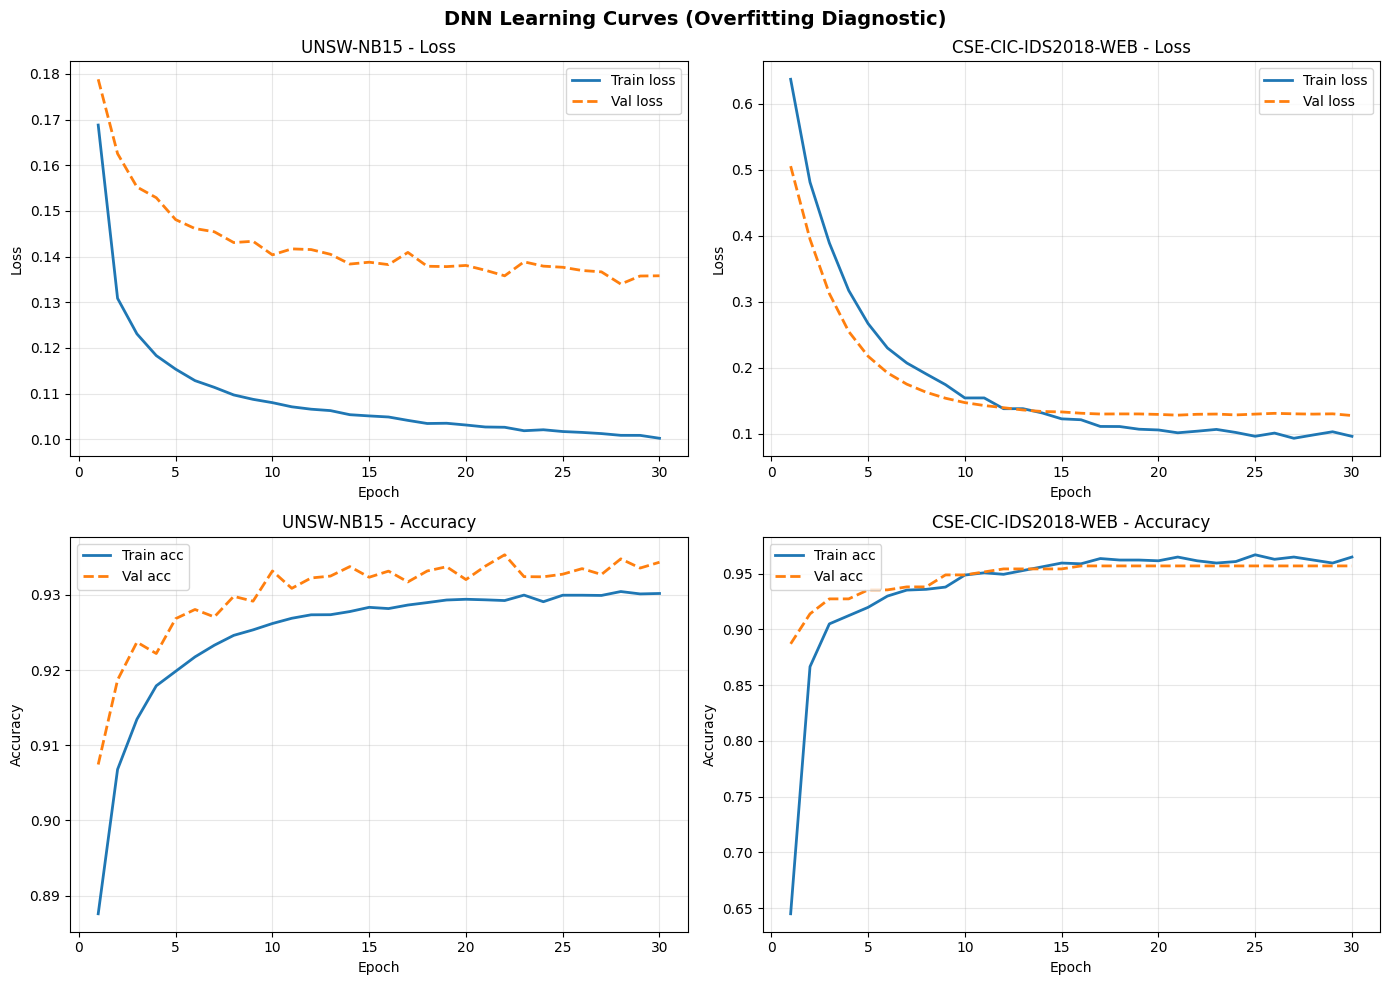


[UNSW-NB15] DNN final gap:
  Accuracy: train=0.9302, val=0.9344, gap=-0.0042
  Loss:     train=0.1002, val=0.1358, gap=+0.0356
  [OK] Val loss stable/decreasing: no overfitting detected

[CSE-CIC-IDS2018-WEB] DNN final gap:
  Accuracy: train=0.9650, val=0.9570, gap=+0.0080
  Loss:     train=0.0961, val=0.1276, gap=+0.0315
  [OK] Val loss stable/decreasing: no overfitting detected


In [7]:
# Cell 8b - DNN Learning Curves (overfitting diagnostic)

# Define outputs_dir at the beginning of the cell
outputs_dir = WORK_DIR / 'VIRTUOSO_pipeline_v9_outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

def train_dnn_with_curves(X, y, dataset_name, test_size=0.2, epochs=30, batch_size=256):
    """
    Train DNN and return full training history for learning curve analysis.
    Uses more epochs than production to show convergence/divergence behaviour.
    """
    X = np.asarray(X, dtype='float32')
    y = np.asarray(y, dtype='float32')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=SEED)

    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)

    n_pos = y_train.sum(); n_neg = len(y_train) - n_pos
    class_w = {0: 1.0, 1: n_neg / (n_pos + 1e-8)}

    tf.random.set_seed(SEED)
    model = build_dnn(input_dim=X_train_s.shape[1])
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy', metrics=['accuracy'])

    # Train WITHOUT early stopping to see full curve behaviour
    history = model.fit(
        X_train_s, y_train,
        validation_data=(X_test_s, y_test),
        batch_size=batch_size, epochs=epochs, verbose=0,
        class_weight=class_w,
    )

    print(f'[{dataset_name}] Final train_loss={history.history["loss"][-1]:.4f}, '
          f'val_loss={history.history["val_loss"][-1]:.4f}, '
          f'train_acc={history.history["accuracy"][-1]:.4f}, '
          f'val_acc={history.history["val_accuracy"][-1]:.4f}')

    return history

# Run on both datasets
print('DNN Learning Curves (30 epochs, no early stopping):')
print('='*60)

hist_unsw = train_dnn_with_curves(
    pd.read_csv(UNSW_X_PATH, low_memory=False).select_dtypes(include=np.number),
    pd.read_csv(UNSW_y_PATH).squeeze().astype(int),
    'UNSW-NB15', epochs=30)

hist_web = None
if IDS_X_WEB_PATH.exists() and IDS_X_WEB_PATH.stat().st_size > 100:
    X_w = pd.read_csv(IDS_X_WEB_PATH, low_memory=False)
    y_w = pd.read_csv(IDS_y_WEB_PATH).squeeze().astype(int)
    if len(X_w) > 0:
        hist_web = train_dnn_with_curves(X_w, y_w, 'CSE-CIC-IDS2018-WEB', epochs=30)

# Plot learning curves
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (hist, ds_name) in enumerate([
    (hist_unsw, 'UNSW-NB15'),
    (hist_web, 'CSE-CIC-IDS2018-WEB'),
]):
    if hist is None:
        for row in range(2):
            axes[row, col].set_title(f'{ds_name} - No data')
        continue

    h = hist.history
    epochs_range = range(1, len(h['loss']) + 1)

    # Loss curves
    ax = axes[0, col]
    ax.plot(epochs_range, h['loss'], label='Train loss', linewidth=2)
    ax.plot(epochs_range, h['val_loss'], label='Val loss', linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'{ds_name} - Loss'); ax.legend(); ax.grid(alpha=0.3)

    # Accuracy curves
    ax = axes[1, col]
    ax.plot(epochs_range, h['accuracy'], label='Train acc', linewidth=2)
    ax.plot(epochs_range, h['val_accuracy'], label='Val acc', linewidth=2, linestyle='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{ds_name} - Accuracy'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('DNN Learning Curves (Overfitting Diagnostic)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(outputs_dir / 'dnn_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Compute final gap
for hist, ds_name in [(hist_unsw, 'UNSW-NB15'), (hist_web, 'CSE-CIC-IDS2018-WEB')]:
    if hist is None: continue
    h = hist.history
    final_train_acc = h['accuracy'][-1]
    final_val_acc   = h['val_accuracy'][-1]
    final_train_loss = h['loss'][-1]
    final_val_loss   = h['val_loss'][-1]
    print(f'\n[{ds_name}] DNN final gap:')
    print(f'  Accuracy: train={final_train_acc:.4f}, val={final_val_acc:.4f}, gap={final_train_acc - final_val_acc:+.4f}')
    print(f'  Loss:     train={final_train_loss:.4f}, val={final_val_loss:.4f}, gap={final_val_loss - final_train_loss:+.4f}')
    # Check for divergence in last 5 epochs
    val_losses_last5 = h['val_loss'][-5:]
    if val_losses_last5[-1] > val_losses_last5[0]:
        print(f'  [WARN] Val loss increasing in last 5 epochs: possible overfitting onset')
    else:
        print(f'  [OK] Val loss stable/decreasing: no overfitting detected')


## Cell T1.0 -- Install Tier 1 Dependencies

In [8]:
# Cell T1.0 - Install Tier 1 libraries
!pip install -q xgboost lightgbm catboost scikit-posthocs

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 26.6 MB/s eta 0:00:00


## Cell T1.1 -- Tier 1 Models with Per-Fold Tracking (v9)
*Returns per-fold raw metrics + summary with mean +/- std.*

In [9]:
# Cell T1.1 - Tier 1 CV with per-fold tracking
# v9.1: adaptive model capacity for small datasets

def run_tier1_cv(X, y, dataset_name, n_splits=5, random_state=SEED):
    X = np.asarray(X, dtype='float32'); y = np.asarray(y, dtype=int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    n_samples = len(y)
    n_features = X.shape[1]

    # Adaptive capacity: constrain models when dataset is small
    if n_samples < 5000:
        print(f'[INFO] Small dataset ({n_samples} samples) -> applying capacity constraints')
        rf_max_depth = 10
        rf_n_estimators = 100
        boost_max_depth = 4
        boost_n_estimators = 150
        rf_max_features = 'sqrt'
        rf_min_samples_leaf = 5
    else:
        rf_max_depth = None
        rf_n_estimators = 300
        boost_max_depth = 6
        boost_n_estimators = 300
        rf_max_features = 'sqrt'
        rf_min_samples_leaf = 1

    model_defs = {
        'RF': RandomForestClassifier(
            n_estimators=rf_n_estimators, max_depth=rf_max_depth,
            max_features=rf_max_features, min_samples_leaf=rf_min_samples_leaf,
            n_jobs=-1, random_state=random_state, class_weight='balanced_subsample'),
        'XGBoost': XGBClassifier(
            n_estimators=boost_n_estimators, max_depth=boost_max_depth,
            learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=1.0, min_child_weight=5,
            eval_metric='logloss', tree_method='hist', n_jobs=-1,
            random_state=random_state),
        'LightGBM': LGBMClassifier(
            n_estimators=boost_n_estimators, max_depth=boost_max_depth,
            learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
            objective='binary', n_jobs=-1, random_state=random_state, verbose=-1),
        'CatBoost': CatBoostClassifier(
            iterations=boost_n_estimators, depth=boost_max_depth,
            learning_rate=0.1, l2_leaf_reg=3.0,
            loss_function='Logloss', verbose=False, random_state=random_state),
    }

    fold_rows = []
    for model_name, base_est in model_defs.items():
        print(f'\n[ Tier 1 / {dataset_name} ] Training: {model_name}')
        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_tr, X_te = X[train_idx], X[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]
            est = clone(base_est)

            t0 = time.perf_counter()
            est.fit(X_tr, y_tr)
            train_time = time.perf_counter() - t0

            t0 = time.perf_counter()
            if hasattr(est, 'predict_proba'):
                y_scores = est.predict_proba(X_te)[:, 1]
            else:
                y_scores = est.predict(X_te).astype(float)
            infer_time = time.perf_counter() - t0

            m = compute_binary_metrics(y_te, y_scores, threshold=0.5)
            y_pred = (y_scores >= 0.5).astype(int)
            tn=((y_pred==0)&(y_te==0)).sum(); fp=((y_pred==1)&(y_te==0)).sum()
            fn=((y_pred==0)&(y_te==1)).sum(); tp=((y_pred==1)&(y_te==1)).sum()
            fpr = fp/(fp+tn) if (fp+tn)>0 else 0.0
            fnr = fn/(fn+tp) if (fn+tp)>0 else 0.0

            fold_rows.append({
                'model': model_name, 'dataset': dataset_name, 'fold': fold_idx,
                'accuracy': m['accuracy'], 'precision': m['precision'],
                'recall': m['recall'], 'f1': m['f1'], 'mcc': m['mcc'],
                'auc_roc': m['auc_roc'], 'auc_pr': m['auc_pr'],
                'fpr': fpr, 'fnr': fnr,
                'train_time_s': train_time, 'infer_time_s': infer_time,
                'n_test': len(y_te),
            })
            print(f'  Fold {fold_idx+1}/{n_splits} - acc={m["accuracy"]:.4f}, '
                  f'f1={m["f1"]:.4f}, auc={m["auc_roc"]:.4f}, train={train_time:.1f}s')

    folds_df = pd.DataFrame(fold_rows)

    metric_cols = ['accuracy','precision','recall','f1','mcc','auc_roc','auc_pr',
                   'fpr','fnr','train_time_s','infer_time_s']
    summary_rows = []
    for mn, grp in folds_df.groupby('model', sort=False):
        row = {'model': mn, 'dataset': dataset_name}
        for col in metric_cols:
            v = grp[col].values
            row[f'{col}_mean'] = float(np.mean(v))
            row[f'{col}_std']  = float(np.std(v, ddof=1))
        summary_rows.append(row)
    summary_df = pd.DataFrame(summary_rows).set_index('model')

    print(f'\n[ Tier 1 / {dataset_name} ] Summary (mean +/- std):')
    disp = pd.DataFrame(index=summary_df.index)
    for col in ['accuracy','precision','recall','f1','mcc','auc_roc']:
        disp[col] = summary_df.apply(
            lambda r: f"{r[f'{col}_mean']:.4f} +/- {r[f'{col}_std']:.4f}", axis=1)
    display(disp)
    return summary_df, folds_df

# UNSW (large dataset -> full capacity)
X_unsw_t1 = pd.read_csv(UNSW_X_PATH, low_memory=False).select_dtypes(include=['number'])
y_unsw_t1 = pd.read_csv(UNSW_y_PATH).squeeze().astype(int)
print(f'[UNSW] {X_unsw_t1.shape[1]} numeric columns, {len(X_unsw_t1)} samples')
unsw_tier1_summary, unsw_tier1_folds = run_tier1_cv(X_unsw_t1, y_unsw_t1, 'UNSW-NB15')

# WEB (small dataset -> constrained capacity)
if IDS_X_WEB_PATH.exists() and IDS_X_WEB_PATH.stat().st_size > 100:
    X_web_t1 = pd.read_csv(IDS_X_WEB_PATH, low_memory=False).select_dtypes(include=['number'])
    y_web_t1 = pd.read_csv(IDS_y_WEB_PATH).squeeze().astype(int)
    if len(X_web_t1) > 0:
        print(f'\n[WEB] {X_web_t1.shape[1]} numeric columns, {len(X_web_t1)} samples')
        web_tier1_summary, web_tier1_folds = run_tier1_cv(X_web_t1, y_web_t1, 'CSE-CIC-IDS2018-WEB')
    else:
        print('[WEB] WARNING: CSV loaded but empty.')
        web_tier1_summary, web_tier1_folds = None, None
else:
    print('[WEB] WARNING: IDS_X_web.csv not found or empty.')
    web_tier1_summary, web_tier1_folds = None, None

[UNSW] 39 numeric columns, 257673 samples

[ Tier 1 / UNSW-NB15 ] Training: RF
  Fold 1/5 - acc=0.9514, f1=0.9619, auc=0.9922, train=24.8s
  Fold 2/5 - acc=0.9492, f1=0.9602, auc=0.9917, train=22.8s
  Fold 3/5 - acc=0.9527, f1=0.9629, auc=0.9926, train=22.9s
  Fold 4/5 - acc=0.9506, f1=0.9613, auc=0.9920, train=22.2s
  Fold 5/5 - acc=0.9504, f1=0.9611, auc=0.9920, train=23.4s

[ Tier 1 / UNSW-NB15 ] Training: XGBoost
  Fold 1/5 - acc=0.9469, f1=0.9582, auc=0.9914, train=1.8s
  Fold 2/5 - acc=0.9465, f1=0.9579, auc=0.9915, train=3.3s
  Fold 3/5 - acc=0.9502, f1=0.9609, auc=0.9922, train=1.9s
  Fold 4/5 - acc=0.9471, f1=0.9584, auc=0.9914, train=1.8s
  Fold 5/5 - acc=0.9475, f1=0.9586, auc=0.9916, train=1.8s

[ Tier 1 / UNSW-NB15 ] Training: LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1/5 - acc=0.9471, f1=0.9584, auc=0.9916, train=1.9s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2/5 - acc=0.9464, f1=0.9578, auc=0.9914, train=1.8s


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1/5 - acc=0.9919, f1=0.9919, auc=0.9994, train=0.1s
  Fold 2/5 - acc=0.9919, f1=0.9919, auc=0.9998, train=0.1s
  Fold 3/5 - acc=0.9919, f1=0.9919, auc=0.9998, train=0.1s


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4/5 - acc=0.9865, f1=0.9864, auc=0.9967, train=0.1s
  Fold 5/5 - acc=0.9919, f1=0.9920, auc=1.0000, train=0.1s

[ Tier 1 / CSE-CIC-IDS2018-WEB ] Training: CatBoost
  Fold 1/5 - acc=0.9946, f1=0.9946, auc=0.9990, train=0.2s
  Fold 2/5 - acc=0.9946, f1=0.9946, auc=0.9998, train=0.2s
  Fold 3/5 - acc=0.9919, f1=0.9919, auc=0.9999, train=0.2s
  Fold 4/5 - acc=0.9838, f1=0.9838, auc=0.9977, train=0.2s
  Fold 5/5 - acc=0.9973, f1=0.9973, auc=1.0000, train=0.2s

[ Tier 1 / CSE-CIC-IDS2018-WEB ] Summary (mean +/- std):


,accuracy,precision,recall,f1,mcc,auc_roc
model,,,,,,
RF,0.9903 +/- 0.0078,0.9924 +/- 0.0048,0.9882 +/- 0.0123,0.9903 +/- 0.0078,0.9807 +/- 0.0154,0.9992 +/- 0.0010
XGBoost,0.9876 +/- 0.0036,0.9850 +/- 0.0057,0.9903 +/- 0.0080,0.9876 +/- 0.0036,0.9753 +/- 0.0072,0.9989 +/- 0.0016
LightGBM,0.9908 +/- 0.0024,0.9914 +/- 0.0047,0.9903 +/- 0.0080,0.9908 +/- 0.0024,0.9817 +/- 0.0048,0.9991 +/- 0.0014
CatBoost,0.9925 +/- 0.0052,0.9946 +/- 0.0038,0.9903 +/- 0.0080,0.9924 +/- 0.0052,0.9849 +/- 0.0104,0.9993 +/- 0.0010


TRAIN/TEST GAP ANALYSIS

[ Gap / UNSW-NB15 ] RF
  Fold 1 - train_acc=0.9975, test_acc=0.9514, gap=+0.0461
  Fold 2 - train_acc=0.9976, test_acc=0.9492, gap=+0.0484
  Fold 3 - train_acc=0.9974, test_acc=0.9527, gap=+0.0447
  Fold 4 - train_acc=0.9974, test_acc=0.9506, gap=+0.0469
  Fold 5 - train_acc=0.9975, test_acc=0.9504, gap=+0.0471

[ Gap / UNSW-NB15 ] XGBoost
  Fold 1 - train_acc=0.9569, test_acc=0.9469, gap=+0.0100
  Fold 2 - train_acc=0.9568, test_acc=0.9465, gap=+0.0104
  Fold 3 - train_acc=0.9560, test_acc=0.9502, gap=+0.0058
  Fold 4 - train_acc=0.9565, test_acc=0.9471, gap=+0.0094
  Fold 5 - train_acc=0.9564, test_acc=0.9475, gap=+0.0089

[ Gap / UNSW-NB15 ] LightGBM


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1 - train_acc=0.9547, test_acc=0.9471, gap=+0.0075


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2 - train_acc=0.9548, test_acc=0.9464, gap=+0.0083


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

  Fold 1 - train_acc=0.9973, test_acc=0.9919, gap=+0.0054
  Fold 2 - train_acc=0.9973, test_acc=0.9919, gap=+0.0054
  Fold 3 - train_acc=0.9960, test_acc=0.9919, gap=+0.0040


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4 - train_acc=0.9993, test_acc=0.9865, gap=+0.0128
  Fold 5 - train_acc=0.9960, test_acc=0.9919, gap=+0.0040

[ Gap / CSE-CIC-IDS2018-WEB ] CatBoost
  Fold 1 - train_acc=0.9987, test_acc=0.9946, gap=+0.0040
  Fold 2 - train_acc=0.9987, test_acc=0.9946, gap=+0.0040
  Fold 3 - train_acc=0.9987, test_acc=0.9919, gap=+0.0067
  Fold 4 - train_acc=0.9993, test_acc=0.9838, gap=+0.0155
  Fold 5 - train_acc=0.9993, test_acc=0.9973, gap=+0.0020

[ Gap / CSE-CIC-IDS2018-WEB ] Summary:


,train_acc,test_acc,gap_acc,train_f1,test_f1,gap_f1,train_auc,test_auc,gap_auc
model,,,,,,,,,
CatBoost,0.9989,0.9925,0.0065,0.9989,0.9924,0.0065,1.0000,0.9993,0.0007
LightGBM,0.9972,0.9908,0.0063,0.9972,0.9908,0.0063,1.0000,0.9991,0.0008
RF,0.9941,0.9903,0.0038,0.9941,0.9903,0.0038,0.9998,0.9992,0.0006
XGBoost,0.9933,0.9876,0.0057,0.9933,0.9876,0.0056,0.9998,0.9989,0.0009


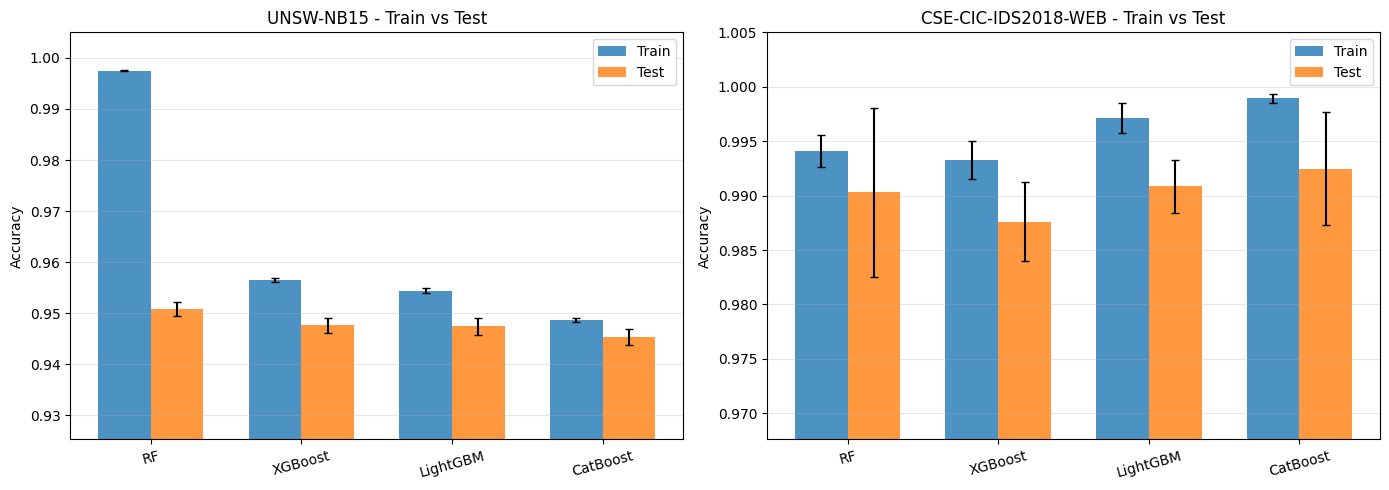


Train/test gap analysis exported.


In [11]:
# Cell T1.1b - Train vs Test accuracy gap (overfitting diagnostic)
# v9.1: uses same adaptive capacity as T1.1

def compute_train_test_gap(X, y, dataset_name, n_splits=5, random_state=SEED):
    X = np.asarray(X, dtype='float32'); y = np.asarray(y, dtype=int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    n_samples = len(y)

    if n_samples < 5000:
        print(f'[INFO] Small dataset ({n_samples} samples) -> capacity constraints applied')
        rf_max_depth = 10
        rf_n_estimators = 100
        boost_max_depth = 4
        boost_n_estimators = 150
        rf_min_samples_leaf = 5
    else:
        rf_max_depth = None
        rf_n_estimators = 300
        boost_max_depth = 6
        boost_n_estimators = 300
        rf_min_samples_leaf = 1

    model_defs = {
        'RF': RandomForestClassifier(
            n_estimators=rf_n_estimators, max_depth=rf_max_depth,
            max_features='sqrt', min_samples_leaf=rf_min_samples_leaf,
            n_jobs=-1, random_state=random_state, class_weight='balanced_subsample'),
        'XGBoost': XGBClassifier(
            n_estimators=boost_n_estimators, max_depth=boost_max_depth,
            learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=1.0, min_child_weight=5,
            eval_metric='logloss', tree_method='hist', n_jobs=-1,
            random_state=random_state),
        'LightGBM': LGBMClassifier(
            n_estimators=boost_n_estimators, max_depth=boost_max_depth,
            learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
            reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
            objective='binary', n_jobs=-1, random_state=random_state, verbose=-1),
        'CatBoost': CatBoostClassifier(
            iterations=boost_n_estimators, depth=boost_max_depth,
            learning_rate=0.1, l2_leaf_reg=3.0,
            loss_function='Logloss', verbose=False, random_state=random_state),
    }

    gap_rows = []
    for model_name, base_est in model_defs.items():
        print(f'\n[ Gap / {dataset_name} ] {model_name}')
        for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y)):
            X_tr, X_te = X[train_idx], X[test_idx]
            y_tr, y_te = y[train_idx], y[test_idx]
            est = clone(base_est)
            est.fit(X_tr, y_tr)

            if hasattr(est, 'predict_proba'):
                y_train_scores = est.predict_proba(X_tr)[:, 1]
                y_test_scores  = est.predict_proba(X_te)[:, 1]
            else:
                y_train_scores = est.predict(X_tr).astype(float)
                y_test_scores  = est.predict(X_te).astype(float)

            train_acc = accuracy_score(y_tr, (y_train_scores >= 0.5).astype(int))
            test_acc  = accuracy_score(y_te, (y_test_scores >= 0.5).astype(int))
            train_f1  = f1_score(y_tr, (y_train_scores >= 0.5).astype(int), zero_division=0)
            test_f1   = f1_score(y_te, (y_test_scores >= 0.5).astype(int), zero_division=0)
            train_auc = roc_auc_score(y_tr, y_train_scores)
            test_auc  = roc_auc_score(y_te, y_test_scores)

            gap_rows.append({
                'model': model_name, 'dataset': dataset_name, 'fold': fold_idx,
                'train_acc': train_acc, 'test_acc': test_acc, 'gap_acc': train_acc - test_acc,
                'train_f1': train_f1, 'test_f1': test_f1, 'gap_f1': train_f1 - test_f1,
                'train_auc': train_auc, 'test_auc': test_auc, 'gap_auc': train_auc - test_auc,
            })
            print(f'  Fold {fold_idx+1} - train_acc={train_acc:.4f}, test_acc={test_acc:.4f}, '
                  f'gap={train_acc - test_acc:+.4f}')

    gap_df = pd.DataFrame(gap_rows)

    print(f'\n[ Gap / {dataset_name} ] Summary:')
    summary = gap_df.groupby('model').agg({
        'train_acc': 'mean', 'test_acc': 'mean', 'gap_acc': 'mean',
        'train_f1': 'mean', 'test_f1': 'mean', 'gap_f1': 'mean',
        'train_auc': 'mean', 'test_auc': 'mean', 'gap_auc': 'mean',
    }).round(4)
    display(summary)
    return gap_df, summary

# UNSW
print('='*60)
print('TRAIN/TEST GAP ANALYSIS')
print('='*60)
gap_unsw_df, gap_unsw_summary = compute_train_test_gap(X_unsw_t1, y_unsw_t1, 'UNSW-NB15')

# WEB
if IDS_X_WEB_PATH.exists() and IDS_X_WEB_PATH.stat().st_size > 100:
    X_web_gap = pd.read_csv(IDS_X_WEB_PATH, low_memory=False).select_dtypes(include=['number'])
    y_web_gap = pd.read_csv(IDS_y_WEB_PATH).squeeze().astype(int)
    if len(X_web_gap) > 0:
        gap_web_df, gap_web_summary = compute_train_test_gap(X_web_gap, y_web_gap, 'CSE-CIC-IDS2018-WEB')
    else:
        gap_web_df, gap_web_summary = None, None
else:
    gap_web_df, gap_web_summary = None, None

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (gap_df, ds_name) in zip(axes, [
    (gap_unsw_df, 'UNSW-NB15'), (gap_web_df, 'CSE-CIC-IDS2018-WEB')]):
    if gap_df is None:
        ax.set_title(f'{ds_name} - No data'); continue
    models = gap_df['model'].unique()
    x = np.arange(len(models))
    train_means = [gap_df[gap_df['model']==m]['train_acc'].mean() for m in models]
    test_means  = [gap_df[gap_df['model']==m]['test_acc'].mean() for m in models]
    train_stds  = [gap_df[gap_df['model']==m]['train_acc'].std() for m in models]
    test_stds   = [gap_df[gap_df['model']==m]['test_acc'].std() for m in models]
    w = 0.35
    ax.bar(x - w/2, train_means, w, yerr=train_stds, label='Train', alpha=0.8, capsize=3)
    ax.bar(x + w/2, test_means, w, yerr=test_stds, label='Test', alpha=0.8, capsize=3)
    ax.set_xticks(x); ax.set_xticklabels(models, rotation=15)
    ax.set_ylabel('Accuracy'); ax.set_title(f'{ds_name} - Train vs Test')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    all_vals = train_means + test_means
    ax.set_ylim(min(all_vals) - 0.02, 1.005)
plt.tight_layout()
plt.savefig(str(outputs_dir / 'train_test_gap.png'), dpi=150, bbox_inches='tight')
plt.show()

gap_unsw_df.to_csv(outputs_dir / 'train_test_gap_unsw.csv', index=False)
if gap_web_df is not None:
    gap_web_df.to_csv(outputs_dir / 'train_test_gap_web.csv', index=False)
print('\nTrain/test gap analysis exported.')

## Cell T1.2 -- Statistical Significance Tests (NEW in v9)
*Friedman test + Nemenyi post-hoc (Demsar 2006).*

In [12]:
# Cell T1.2 - Friedman + Nemenyi
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare

def run_statistical_tests(folds_df, dataset_name, metric='accuracy', alpha=0.05):
    pivot = folds_df.pivot(index='fold', columns='model', values=metric)
    model_names = pivot.columns.tolist()
    print(f'\n{"="*60}')
    print(f'Statistical tests - {dataset_name} - {metric}')
    print(f'{"="*60}')
    display(pivot.round(6))

    arrays = [pivot[m].values for m in model_names]
    stat, p_val = friedmanchisquare(*arrays)
    reject = p_val < alpha
    tag = 'REJECT' if reject else 'fail to reject'
    print(f'\nFriedman chi2 = {stat:.4f}, p = {p_val:.6f}  -> {tag} H0 (alpha={alpha})')

    result = {'dataset': dataset_name, 'metric': metric,
              'friedman_chi2': stat, 'friedman_p': p_val, 'reject_h0': reject}

    nemenyi_df = None
    if reject:
        print('\nNemenyi post-hoc p-values:')
        nemenyi_df = sp.posthoc_nemenyi_friedman(pivot.values)
        nemenyi_df.index = model_names; nemenyi_df.columns = model_names
        display(nemenyi_df.round(4))
    else:
        print('(Nemenyi skipped - Friedman not significant)')
    return result, nemenyi_df

stat_results = []
for folds_df, ds in [(unsw_tier1_folds, 'UNSW-NB15'),
                      (web_tier1_folds, 'CSE-CIC-IDS2018-WEB')]:
    if folds_df is None:
        print(f'\n[SKIP] {ds} - no fold data available')
        continue
    for metric in ['accuracy', 'f1', 'mcc', 'auc_roc']:
        fr, _ = run_statistical_tests(folds_df, ds, metric=metric)
        stat_results.append(fr)

stat_results_df = pd.DataFrame(stat_results)
print('\nFriedman test summary:')
display(stat_results_df)


Statistical tests - UNSW-NB15 - accuracy


model,CatBoost,LightGBM,RF,XGBoost
fold,,,,
0,0.944562,0.947143,0.951392,0.946852
1,0.944193,0.946444,0.949180,0.946464
2,0.948152,0.950325,0.952673,0.950228
3,0.944697,0.947142,0.950557,0.947064
4,0.944871,0.946288,0.950363,0.947510



Friedman chi2 = 13.5600, p = 0.003570  -> REJECT H0 (alpha=0.05)

Nemenyi post-hoc p-values:


,CatBoost,LightGBM,RF,XGBoost
CatBoost,1.0000,0.2035,0.0014,0.3159
LightGBM,0.2035,1.0000,0.3159,0.9948
RF,0.0014,0.3159,1.0000,0.2035
XGBoost,0.3159,0.9948,0.2035,1.0000



Statistical tests - UNSW-NB15 - f1


...

model,CatBoost,LightGBM,RF,XGBoost
fold,,,,
0,0.989247,0.983885,0.978495,0.978495
1,0.989275,0.983841,0.983841,0.983842
2,0.983841,0.983842,1.000000,0.967712
3,0.967712,0.973174,0.957098,0.967712
4,0.994624,0.983955,0.983841,0.978663



Friedman chi2 = 4.9149, p = 0.178136  -> fail to reject H0 (alpha=0.05)
(Nemenyi skipped - Friedman not significant)

Statistical tests - CSE-CIC-IDS2018-WEB - auc_roc


model,CatBoost,LightGBM,RF,XGBoost
fold,,,,
0,0.998988,0.999422,0.998902,0.999538
1,0.999797,0.999768,0.999709,0.999535
2,0.999942,0.999826,1.000000,0.999419
3,0.997704,0.996687,0.997559,0.995960
4,0.999956,0.999985,0.999651,0.999869



Friedman chi2 = 3.4800, p = 0.323365  -> fail to reject H0 (alpha=0.05)
(Nemenyi skipped - Friedman not significant)

Friedman test summary:


,dataset,metric,friedman_chi2,friedman_p,reject_h0
0,UNSW-NB15,accuracy,13.560000,0.003570,True
1,UNSW-NB15,f1,13.560000,0.003570,True
2,UNSW-NB15,mcc,14.040000,0.002851,True
3,UNSW-NB15,auc_roc,13.560000,0.003570,True
4,CSE-CIC-IDS2018-WEB,accuracy,6.428571,0.092522,False
5,CSE-CIC-IDS2018-WEB,f1,4.914894,0.178136,False
6,CSE-CIC-IDS2018-WEB,mcc,4.914894,0.178136,False
7,CSE-CIC-IDS2018-WEB,auc_roc,3.480000,0.323365,False


## Cell T1.3 -- Paper-Ready Table 4 (NEW in v9)

In [13]:
# Cell T1.3 - Paper-ready table + exports
outputs_dir = WORK_DIR / 'VIRTUOSO_pipeline_v9_outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

def build_paper_table(*summary_dfs):
    metrics = ['accuracy','precision','recall','f1','auc_roc','fpr','fnr','mcc']
    rows = []
    for sdf in summary_dfs:
        sdf_r = sdf.reset_index()
        for _, row in sdf_r.iterrows():
            r = {'Model': row['model'], 'Dataset': row['dataset']}
            for m in metrics:
                r[m.upper()] = f"{row[f'{m}_mean']:.4f} +/- {row[f'{m}_std']:.4f}"
            r['Train(s)'] = f"{row['train_time_s_mean']:.1f}+/-{row['train_time_s_std']:.1f}"
            r['Infer(s)'] = f"{row['infer_time_s_mean']:.2f}+/-{row['infer_time_s_std']:.2f}"
            rows.append(r)
    return pd.DataFrame(rows)

valid_summaries = [s for s in [unsw_tier1_summary, web_tier1_summary] if s is not None]
paper_table = build_paper_table(*valid_summaries)

# Append DNN
for dnn_m, ds in [(dnn_unsw_metrics,'UNSW-NB15'),(dnn_web_metrics,'CSE-CIC-IDS2018-WEB')]:
    r = {'Model':'DNN','Dataset':ds}
    for m in ['accuracy','precision','recall','f1','auc_roc','fpr','fnr','mcc']:
        if m in dnn_m.columns:
            r[m.upper()] = f"{dnn_m[m].mean():.4f} +/- {dnn_m[m].std():.4f}"
    r['Train(s)'] = f"{dnn_m['train_time_s'].mean():.1f}+/-{dnn_m['train_time_s'].std():.1f}"
    r['Infer(s)'] = f"{dnn_m['infer_time_s'].mean():.2f}+/-{dnn_m['infer_time_s'].std():.2f}"
    paper_table = pd.concat([paper_table, pd.DataFrame([r])], ignore_index=True)

print('Table 4 (revised) - Performance with Confidence Intervals:')
display(paper_table)

paper_table.to_csv(outputs_dir / 'table4_revised_mean_std.csv', index=False)
unsw_tier1_folds.to_csv(outputs_dir / 'unsw_tier1_perfold.csv', index=False)
if web_tier1_folds is not None:
    web_tier1_folds.to_csv(outputs_dir / 'web_tier1_perfold.csv', index=False)
stat_results_df.to_csv(outputs_dir / 'friedman_tests.csv', index=False)
dnn_unsw_metrics.to_csv(outputs_dir / 'dnn_unsw_repeated.csv', index=False)
dnn_web_metrics.to_csv(outputs_dir / 'dnn_web_repeated.csv', index=False)
print('All Point 1 artefacts exported.')

Table 4 (revised) - Performance with Confidence Intervals:


,Model,Dataset,ACCURACY,PRECISION,RECALL,F1,AUC_ROC,FPR,FNR,MCC,Train(s),Infer(s)
0,RF,UNSW-NB15,0.9508 +/- 0.0013,0.9623 +/- 0.0015,0.9607 +/- 0.0014,0.9615 +/- 0.0010,0.9921 +/- 0.0003,0.0666 +/- 0.0028,0.0393 +/- 0.0014,0.8935 +/- 0.0028,23.2+/-1.0,0.22+/-0.02
1,XGBoost,UNSW-NB15,0.9476 +/- 0.0015,0.9635 +/- 0.0016,0.9542 +/- 0.0021,0.9588 +/- 0.0012,0.9916 +/- 0.0003,0.0641 +/- 0.0029,0.0458 +/- 0.0021,0.8870 +/- 0.0032,2.1+/-0.6,0.05+/-0.01
2,LightGBM,UNSW-NB15,0.9475 +/- 0.0016,0.9645 +/- 0.0012,0.9528 +/- 0.0023,0.9586 +/- 0.0013,0.9916 +/- 0.0003,0.0621 +/- 0.0021,0.0472 +/- 0.0023,0.8868 +/- 0.0035,2.4+/-0.8,0.10+/-0.00
3,CatBoost,UNSW-NB15,0.9453 +/- 0.0016,0.9609 +/- 0.0019,0.9532 +/- 0.0025,0.9570 +/- 0.0013,0.9908 +/- 0.0004,0.0687 +/- 0.0036,0.0468 +/- 0.0025,0.8818 +/- 0.0035,4.8+/-0.4,0.01+/-0.00
4,RF,CSE-CIC-IDS2018-WEB,0.9903 +/- 0.0078,0.9924 +/- 0.0048,0.9882 +/- 0.0123,0.9903 +/- 0.0078,0.9992 +/- 0.0010,0.0076 +/- 0.0048,0.0118 +/- 0.0123,0.9807 +/- 0.0154,0.3+/-0.0,0.03+/-0.01
5,XGBoost,CSE-CIC-IDS2018-WEB,0.9876 +/- 0.0036,0.9850 +/- 0.0057,0.9903 +/- 0.0080,0.9876 +/- 0.0036,0.9989 +/- 0.0016,0.0151 +/- 0.0059,0.0097 +/- 0.0080,0.9753 +/- 0.0072,0.1+/-0.0,0.00+/-0.00
6,LightGBM,CSE-CIC-IDS2018-WEB,0.9908 +/- 0.0024,0.9914 +/- 0.0047,0.9903 +/- 0.0080,0.9908 +/- 0.0024,0.9991 +/- 0.0014,0.0086 +/- 0.0048,0.0097 +/- 0.0080,0.9817 +/- 0.0048,0.1+/-0.0,0.00+/-0.00
7,CatBoost,CSE-CIC-IDS2018-WEB,0.9925 +/- 0.0052,0.9946 +/- 0.0038,0.9903 +/- 0.0080,0.9924 +/- 0.0052,0.9993 +/- 0.0010,0.0054 +/- 0.0038,0.0097 +/- 0.0080,0.9849 +/- 0.0104,0.2+/-0.0,0.00+/-0.00
8,DNN,UNSW-NB15,0.9304 +/- 0.0019,0.9706 +/- 0.0022,0.9189 +/- 0.0047,0.9440 +/- 0.0017,0.9869 +/- 0.0003,0.0494 +/- 0.0041,0.0811 +/- 0.0047,0.8543 +/- 0.0033,28.1+/-1.6,1.29+/-0.63
9,DNN,CSE-CIC-IDS2018-WEB,0.9538 +/- 0.0082,0.9196 +/- 0.0136,0.9946 +/- 0.0038,0.9556 +/- 0.0075,0.9937 +/- 0.0020,0.0871 +/- 0.0159,0.0054 +/- 0.0038,0.9107 +/- 0.0153,6.3+/-0.6,0.97+/-0.62


All Point 1 artefacts exported.


REVISED FIGURES (Bar Charts + ROC)

--- Figure 5: UNSW-NB15 ---


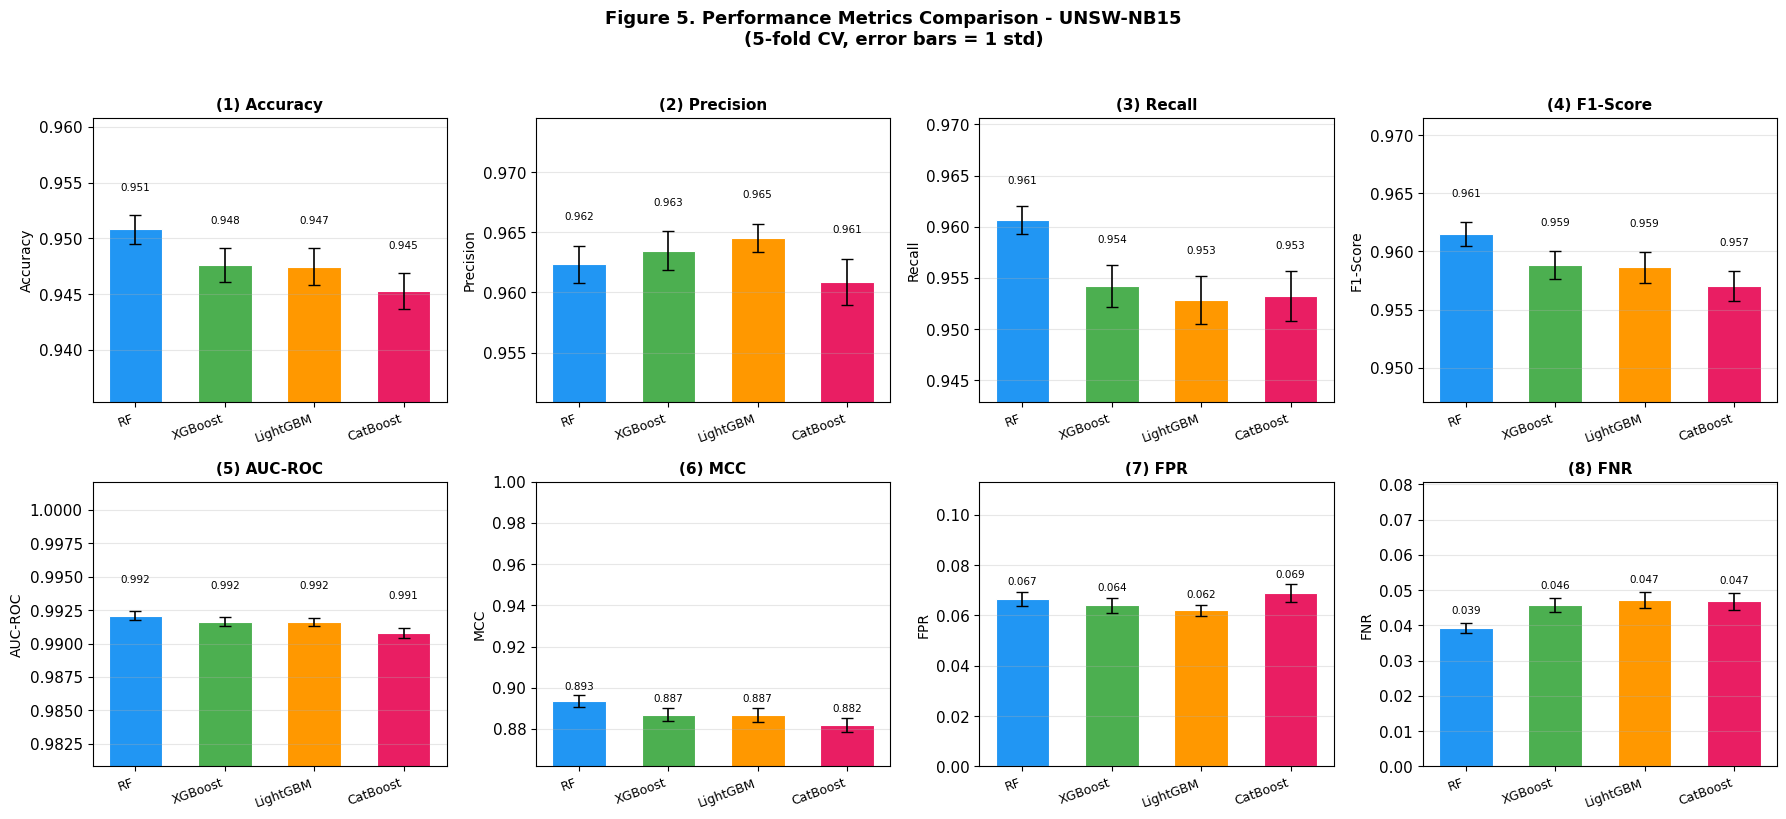

[Saved] /content/virtuoso/VIRTUOSO_pipeline_v9_outputs/fig5_unsw_bar_metrics.png


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


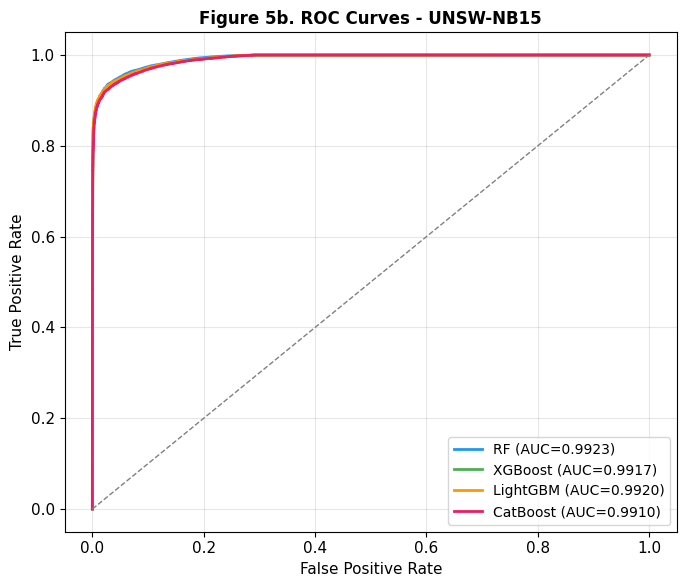

[Saved] /content/virtuoso/VIRTUOSO_pipeline_v9_outputs/fig5_unsw_roc_roc_comparison.png

--- Figure 6: CSE-CIC-IDS2018-WEB ---


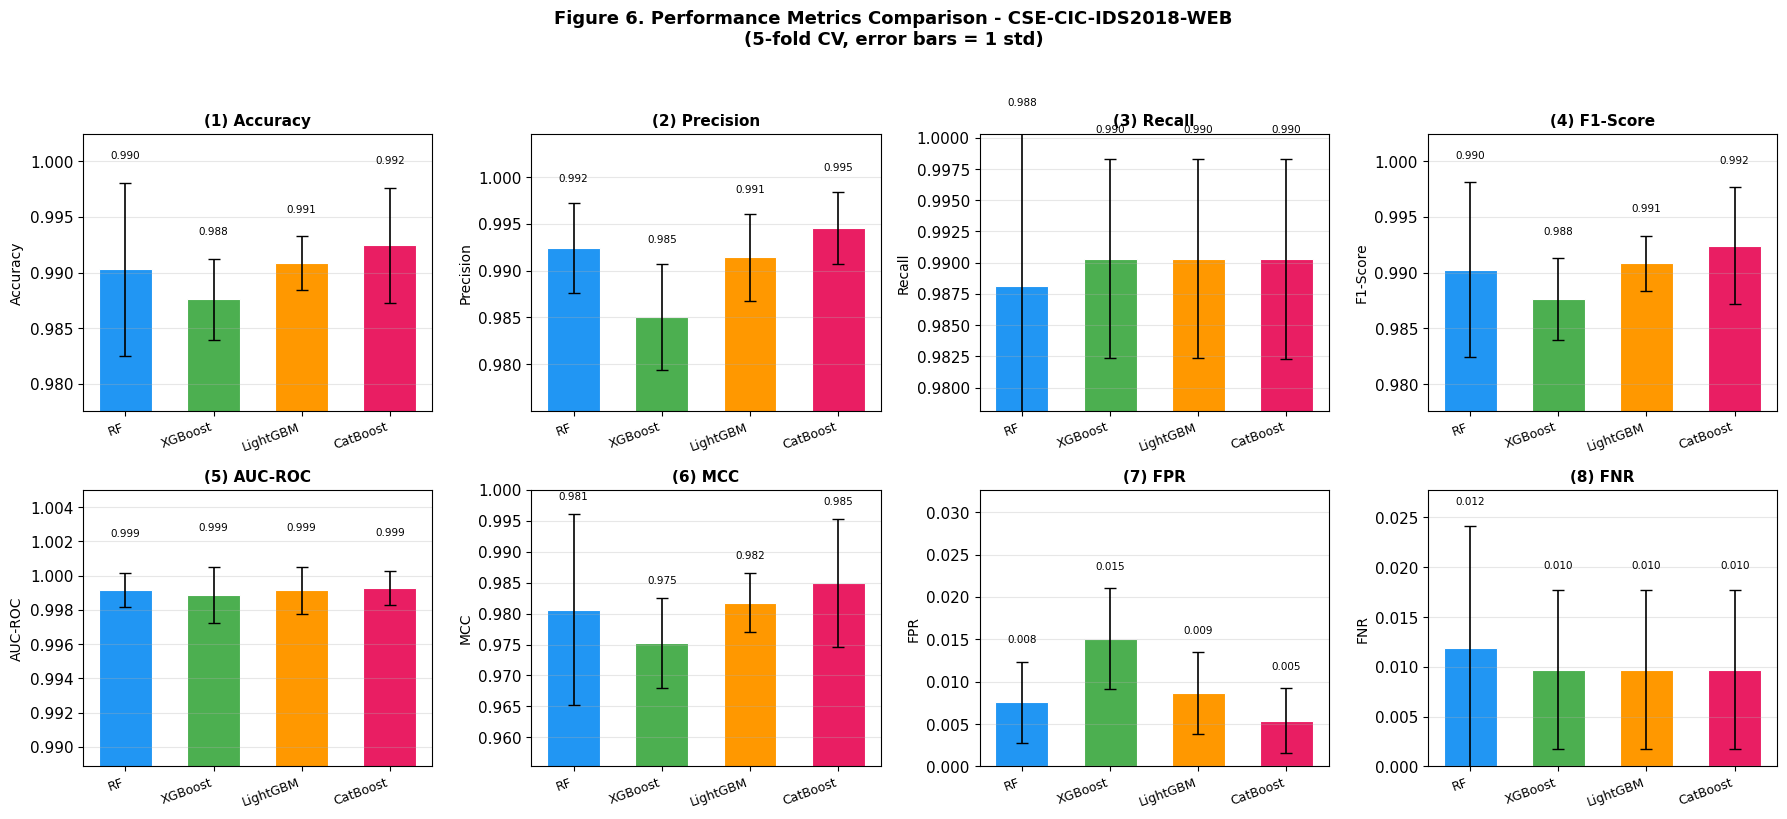

[Saved] /content/virtuoso/VIRTUOSO_pipeline_v9_outputs/fig6_web_bar_metrics.png


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


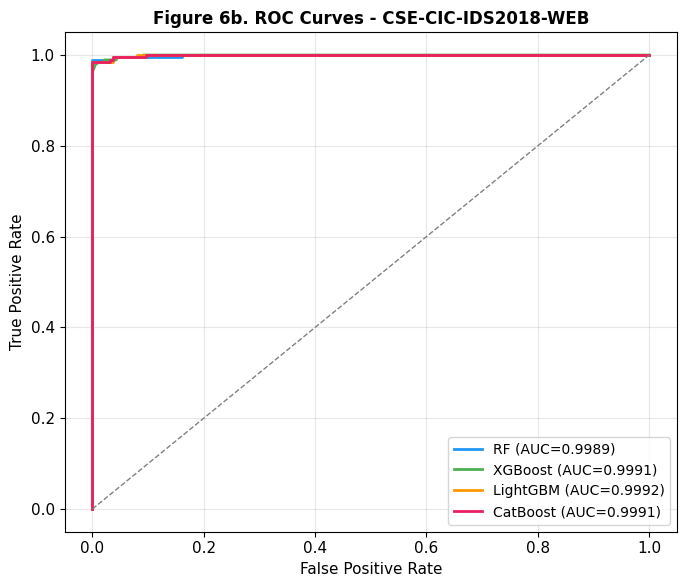

[Saved] /content/virtuoso/VIRTUOSO_pipeline_v9_outputs/fig6_web_roc_roc_comparison.png

All revised figures saved to /content/virtuoso/VIRTUOSO_pipeline_v9_outputs


In [22]:
# Cell T1.4 - Revised Figures 5 & 6: Bar charts with algorithms on X-axis
# Replaces the original line plots (Reviewer 3 #8)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11})

def plot_metric_bars(folds_df, dataset_name, output_prefix, fig_label='Figure'):
    metrics = [
        ('accuracy', 'Accuracy'),
        ('precision', 'Precision'),
        ('recall', 'Recall'),
        ('f1', 'F1-Score'),
        ('auc_roc', 'AUC-ROC'),
        ('mcc', 'MCC'),
        ('fpr', 'FPR'),
        ('fnr', 'FNR'),
    ]

    models = folds_df['model'].unique()
    summary = {}
    for m_key, m_label in metrics:
        means = [folds_df[folds_df['model']==mod][m_key].mean() for mod in models]
        stds  = [folds_df[folds_df['model']==mod][m_key].std() for mod in models]
        summary[m_key] = {'label': m_label, 'means': means, 'stds': stds}

    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    axes = axes.flatten()

    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    if len(models) > len(colors):
        colors = plt.cm.Set2(np.linspace(0, 1, len(models)))

    for idx, (m_key, m_label) in enumerate(metrics):
        ax = axes[idx]
        x = np.arange(len(models))
        means = summary[m_key]['means']
        stds  = summary[m_key]['stds']

        bars = ax.bar(x, means, yerr=stds, capsize=4, width=0.6,
                       color=colors[:len(models)], edgecolor='white', linewidth=0.8,
                       error_kw={'linewidth': 1.2})

        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
        ax.set_ylabel(m_label, fontsize=10)
        ax.set_title(f'({idx+1}) {m_label}', fontsize=11, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)

        if m_key in ['fpr', 'fnr']:
            ax.set_ylim(0, max(means) * 1.5 + 0.01)
        elif m_key == 'mcc':
            ax.set_ylim(min(means) - 0.02, 1.0)
        else:
            ax.set_ylim(min(means) - 0.01, min(max(means) + 0.01, 1.005))

        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + std + 0.002,
                    f'{mean:.3f}', ha='center', va='bottom', fontsize=7.5)

    fig.suptitle(f'{fig_label}. Performance Metrics Comparison - {dataset_name}\n'
                 f'(5-fold CV, error bars = 1 std)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()

    out_path = outputs_dir / f'{output_prefix}_bar_metrics.png'
    plt.savefig(str(out_path), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'[Saved] {out_path}')
    return out_path


def plot_roc_comparison(folds_df, X_data, y_data, dataset_name, output_prefix, fig_label='Figure'):
    from sklearn.base import clone

    n_samples = len(y_data)
    if n_samples < 5000:
        models_def = {
            'RF': RandomForestClassifier(n_estimators=100, max_depth=10,
                  max_features='sqrt', min_samples_leaf=5,
                  n_jobs=-1, random_state=SEED, class_weight='balanced_subsample'),
            'XGBoost': XGBClassifier(n_estimators=150, max_depth=4,
                       learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=1.0, reg_lambda=1.0, min_child_weight=5,
                       eval_metric='logloss', tree_method='hist', n_jobs=-1,
                       random_state=SEED),
            'LightGBM': LGBMClassifier(n_estimators=150, max_depth=4,
                        learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
                        objective='binary', n_jobs=-1, random_state=SEED, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=150, depth=4,
                        learning_rate=0.1, l2_leaf_reg=3.0,
                        loss_function='Logloss', verbose=False, random_state=SEED),
        }
    else:
        models_def = {
            'RF': RandomForestClassifier(n_estimators=300, max_depth=None,
                  n_jobs=-1, random_state=SEED, class_weight='balanced_subsample'),
            'XGBoost': XGBClassifier(n_estimators=300, max_depth=6,
                       learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                       reg_alpha=1.0, reg_lambda=1.0, min_child_weight=5,
                       eval_metric='logloss', tree_method='hist', n_jobs=-1,
                       random_state=SEED),
            'LightGBM': LGBMClassifier(n_estimators=300, max_depth=-1,
                        learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
                        reg_alpha=1.0, reg_lambda=1.0, min_child_samples=10,
                        objective='binary', n_jobs=-1, random_state=SEED, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=300, depth=6,
                        learning_rate=0.1, l2_leaf_reg=3.0,
                        loss_function='Logloss', verbose=False, random_state=SEED),
        }

    X = np.asarray(X_data, dtype='float32')
    y = np.asarray(y_data, dtype=int)

    from sklearn.model_selection import train_test_split
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

    fig, ax = plt.subplots(1, 1, figsize=(7, 6))
    colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

    for (name, base_est), color in zip(models_def.items(), colors):
        est = clone(base_est)
        est.fit(X_tr, y_tr)
        if hasattr(est, 'predict_proba'):
            y_scores = est.predict_proba(X_te)[:, 1]
        else:
            y_scores = est.predict(X_te).astype(float)
        fpr_vals, tpr_vals, _ = roc_curve(y_te, y_scores)
        auc_val = auc(fpr_vals, tpr_vals)
        ax.plot(fpr_vals, tpr_vals, label=f'{name} (AUC={auc_val:.4f})', color=color, linewidth=2)

    ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{fig_label}. ROC Curves - {dataset_name}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(alpha=0.3)

    out_path = outputs_dir / f'{output_prefix}_roc_comparison.png'
    plt.tight_layout()
    plt.savefig(str(out_path), dpi=200, bbox_inches='tight')
    plt.show()
    print(f'[Saved] {out_path}')
    return out_path


# ============================================================
# Generate revised Figure 5 (UNSW-NB15)
# ============================================================
print('='*60)
print('REVISED FIGURES (Bar Charts + ROC)')
print('='*60)

print('\n--- Figure 5: UNSW-NB15 ---')
plot_metric_bars(unsw_tier1_folds, 'UNSW-NB15', 'fig5_unsw', fig_label='Figure 5')
plot_roc_comparison(unsw_tier1_folds, X_unsw_t1, y_unsw_t1, 'UNSW-NB15', 'fig5_unsw_roc', fig_label='Figure 5b')

# ============================================================
# Generate revised Figure 6 (CSE-CIC-IDS2018-WEB)
# ============================================================
if web_tier1_folds is not None:
    print('\n--- Figure 6: CSE-CIC-IDS2018-WEB ---')
    X_web_fig = pd.read_csv(IDS_X_WEB_PATH, low_memory=False).select_dtypes(include=['number'])
    y_web_fig = pd.read_csv(IDS_y_WEB_PATH).squeeze().astype(int)
    plot_metric_bars(web_tier1_folds, 'CSE-CIC-IDS2018-WEB', 'fig6_web', fig_label='Figure 6')
    plot_roc_comparison(web_tier1_folds, X_web_fig, y_web_fig, 'CSE-CIC-IDS2018-WEB', 'fig6_web_roc', fig_label='Figure 6b')
else:
    print('[SKIP] Figure 6: no WEB fold data')

print('\nAll revised figures saved to', outputs_dir)

HYPERPARAMETER SENSITIVITY ANALYSIS

[UNSW-NB15] RF sensitivity to max_depth (n_estimators=300):
  max_depth=    6 -> acc=0.9179 +/- 0.0024
  max_depth=   10 -> acc=0.9307 +/- 0.0018
  max_depth=   15 -> acc=0.9403 +/- 0.0021
  max_depth=   20 -> acc=0.9465 +/- 0.0020
  max_depth=   30 -> acc=0.9504 +/- 0.0016
  max_depth= None -> acc=0.9509 +/- 0.0013

[UNSW-NB15] RF sensitivity to n_estimators (max_depth=None):
  n_estimators=  50 -> acc=0.9501 +/- 0.0014
  n_estimators= 100 -> acc=0.9507 +/- 0.0014
  n_estimators= 200 -> acc=0.9508 +/- 0.0011
  n_estimators= 300 -> acc=0.9509 +/- 0.0013
  n_estimators= 500 -> acc=0.9511 +/- 0.0014

[CSE-CIC-IDS2018-WEB] RF sensitivity to max_depth (n_estimators=100):
  max_depth=    4 -> acc=0.9634 +/- 0.0082
  max_depth=    6 -> acc=0.9838 +/- 0.0076
  max_depth=    8 -> acc=0.9903 +/- 0.0078
  max_depth=   10 -> acc=0.9903 +/- 0.0078
  max_depth=   15 -> acc=0.9903 +/- 0.0078
  max_depth= None -> acc=0.9903 +/- 0.0078

[CSE-CIC-IDS2018-WEB] RF sen

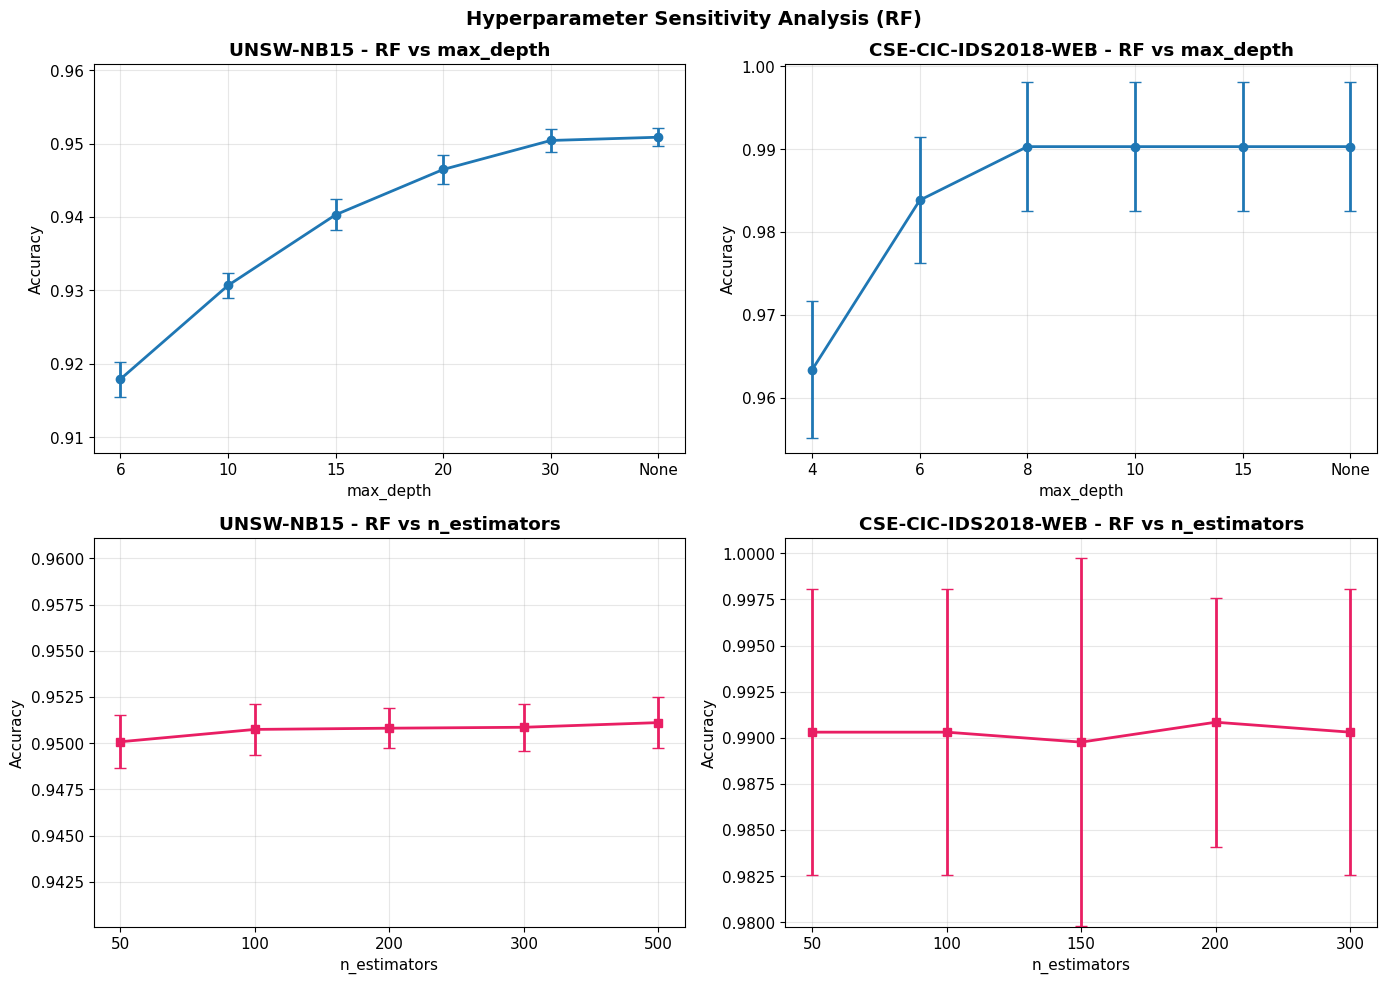


Hyperparameter sensitivity exported.


,dataset,param,value,accuracy_mean,accuracy_std
0,UNSW-NB15,max_depth,6,0.917900,0.002389
1,UNSW-NB15,max_depth,10,0.930664,0.001752
2,UNSW-NB15,max_depth,15,0.940293,0.002128
3,UNSW-NB15,max_depth,20,0.946467,0.002028
4,UNSW-NB15,max_depth,30,0.950418,0.001576
5,UNSW-NB15,max_depth,None,0.950860,0.001262
6,UNSW-NB15,n_estimators,50,0.950076,0.001429
7,UNSW-NB15,n_estimators,100,0.950744,0.001366
8,UNSW-NB15,n_estimators,200,0.950810,0.001078
9,UNSW-NB15,n_estimators,300,0.950860,0.001262


In [23]:
# Cell T1.5 - Hyperparameter Sensitivity Analysis (Reviewer 2)
# Tests key hyperparameters on the best model (RF) across both datasets

from sklearn.base import clone

def hyperparameter_sensitivity(X, y, dataset_name, random_state=SEED):
    X = np.asarray(X, dtype='float32'); y = np.asarray(y, dtype=int)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    n_samples = len(y)

    # Define parameter grid for RF
    if n_samples < 5000:
        depth_values = [4, 6, 8, 10, 15, None]
        n_est_values = [50, 100, 150, 200, 300]
    else:
        depth_values = [6, 10, 15, 20, 30, None]
        n_est_values = [50, 100, 200, 300, 500]

    results = []

    # --- Sensitivity to max_depth (fixed n_estimators) ---
    fixed_n_est = 100 if n_samples < 5000 else 300
    print(f'\n[{dataset_name}] RF sensitivity to max_depth (n_estimators={fixed_n_est}):')
    for depth in depth_values:
        accs = []
        for train_idx, test_idx in skf.split(X, y):
            est = RandomForestClassifier(
                n_estimators=fixed_n_est, max_depth=depth,
                max_features='sqrt', min_samples_leaf=5 if n_samples < 5000 else 1,
                n_jobs=-1, random_state=random_state, class_weight='balanced_subsample')
            est.fit(X[train_idx], y[train_idx])
            y_pred = est.predict(X[test_idx])
            accs.append(accuracy_score(y[test_idx], y_pred))
        mean_acc = np.mean(accs); std_acc = np.std(accs, ddof=1)
        results.append({'dataset': dataset_name, 'param': 'max_depth',
                        'value': str(depth), 'accuracy_mean': mean_acc,
                        'accuracy_std': std_acc})
        print(f'  max_depth={str(depth):>5s} -> acc={mean_acc:.4f} +/- {std_acc:.4f}')

    # --- Sensitivity to n_estimators (fixed max_depth) ---
    fixed_depth = 10 if n_samples < 5000 else None
    print(f'\n[{dataset_name}] RF sensitivity to n_estimators (max_depth={fixed_depth}):')
    for n_est in n_est_values:
        accs = []
        for train_idx, test_idx in skf.split(X, y):
            est = RandomForestClassifier(
                n_estimators=n_est, max_depth=fixed_depth,
                max_features='sqrt', min_samples_leaf=5 if n_samples < 5000 else 1,
                n_jobs=-1, random_state=random_state, class_weight='balanced_subsample')
            est.fit(X[train_idx], y[train_idx])
            y_pred = est.predict(X[test_idx])
            accs.append(accuracy_score(y[test_idx], y_pred))
        mean_acc = np.mean(accs); std_acc = np.std(accs, ddof=1)
        results.append({'dataset': dataset_name, 'param': 'n_estimators',
                        'value': str(n_est), 'accuracy_mean': mean_acc,
                        'accuracy_std': std_acc})
        print(f'  n_estimators={n_est:>4d} -> acc={mean_acc:.4f} +/- {std_acc:.4f}')

    return pd.DataFrame(results)

# Run on both datasets
print('='*60)
print('HYPERPARAMETER SENSITIVITY ANALYSIS')
print('='*60)

sens_unsw = hyperparameter_sensitivity(X_unsw_t1, y_unsw_t1, 'UNSW-NB15')

if IDS_X_WEB_PATH.exists() and IDS_X_WEB_PATH.stat().st_size > 100:
    X_web_sens = pd.read_csv(IDS_X_WEB_PATH, low_memory=False).select_dtypes(include=['number'])
    y_web_sens = pd.read_csv(IDS_y_WEB_PATH).squeeze().astype(int)
    sens_web = hyperparameter_sensitivity(X_web_sens, y_web_sens, 'CSE-CIC-IDS2018-WEB')
    sens_all = pd.concat([sens_unsw, sens_web], ignore_index=True)
else:
    sens_all = sens_unsw

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for col, (ds_name, ds_df) in enumerate([
    ('UNSW-NB15', sens_unsw),
    ('CSE-CIC-IDS2018-WEB', sens_web if 'sens_web' in dir() else None),
]):
    if ds_df is None:
        for row in range(2):
            axes[row, col].set_title(f'{ds_name} - No data')
        continue

    # max_depth subplot
    ax = axes[0, col]
    depth_df = ds_df[ds_df['param'] == 'max_depth']
    x_labels = depth_df['value'].values
    means = depth_df['accuracy_mean'].values
    stds = depth_df['accuracy_std'].values
    x = np.arange(len(x_labels))
    ax.errorbar(x, means, yerr=stds, marker='o', capsize=4, linewidth=2, markersize=6)
    ax.set_xticks(x); ax.set_xticklabels(x_labels)
    ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{ds_name} - RF vs max_depth', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim(min(means) - 0.01, max(means) + 0.01)

    # n_estimators subplot
    ax = axes[1, col]
    nest_df = ds_df[ds_df['param'] == 'n_estimators']
    x_labels = nest_df['value'].values
    means = nest_df['accuracy_mean'].values
    stds = nest_df['accuracy_std'].values
    x = np.arange(len(x_labels))
    ax.errorbar(x, means, yerr=stds, marker='s', capsize=4, linewidth=2, markersize=6, color='#E91E63')
    ax.set_xticks(x); ax.set_xticklabels(x_labels)
    ax.set_xlabel('n_estimators'); ax.set_ylabel('Accuracy')
    ax.set_title(f'{ds_name} - RF vs n_estimators', fontweight='bold')
    ax.grid(alpha=0.3)
    ax.set_ylim(min(means) - 0.01, max(means) + 0.01)

plt.suptitle('Hyperparameter Sensitivity Analysis (RF)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(str(outputs_dir / 'hyperparameter_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

sens_all.to_csv(outputs_dir / 'hyperparameter_sensitivity.csv', index=False)
print('\nHyperparameter sensitivity exported.')
display(sens_all)

In [24]:
# Cell T1.6 - Computational Cost Table (Reviewer 2)
# Summarises training time, inference time, and throughput per model

def build_cost_table(folds_df, dataset_name, n_test_samples=None):
    rows = []
    for model_name, grp in folds_df.groupby('model', sort=False):
        train_t = grp['train_time_s'].values
        infer_t = grp['infer_time_s'].values
        n_test = grp['n_test'].values[0]  # same across folds

        # Throughput: samples per second at inference
        throughput = n_test / infer_t  # per fold

        rows.append({
            'Model': model_name,
            'Dataset': dataset_name,
            'Train Time (s)': f'{train_t.mean():.2f} +/- {train_t.std(ddof=1):.2f}',
            'Infer Time (s)': f'{infer_t.mean():.3f} +/- {infer_t.std(ddof=1):.3f}',
            'Throughput (samples/s)': f'{throughput.mean():.0f} +/- {throughput.std(ddof=1):.0f}',
            'train_mean': train_t.mean(),
            'infer_mean': infer_t.mean(),
            'throughput_mean': throughput.mean(),
        })
    return pd.DataFrame(rows)

print('='*60)
print('COMPUTATIONAL COST ANALYSIS')
print('='*60)

# Channel 1 ensembles
cost_unsw = build_cost_table(unsw_tier1_folds, 'UNSW-NB15')
print('\n[UNSW-NB15] Ensemble costs:')
display(cost_unsw[['Model', 'Dataset', 'Train Time (s)', 'Infer Time (s)', 'Throughput (samples/s)']])

cost_web = None
if web_tier1_folds is not None:
    cost_web = build_cost_table(web_tier1_folds, 'CSE-CIC-IDS2018-WEB')
    print('\n[CSE-CIC-IDS2018-WEB] Ensemble costs:')
    display(cost_web[['Model', 'Dataset', 'Train Time (s)', 'Infer Time (s)', 'Throughput (samples/s)']])

# DNN costs
print('\n[DNN] Costs:')
for dnn_m, ds in [(dnn_unsw_metrics, 'UNSW-NB15'), (dnn_web_metrics, 'CSE-CIC-IDS2018-WEB')]:
    if dnn_m is None or dnn_m.empty:
        continue
    tt = dnn_m['train_time_s'].values
    it = dnn_m['infer_time_s'].values
    print(f'  {ds}: train={tt.mean():.1f}+/-{tt.std():.1f}s, infer={it.mean():.3f}+/-{it.std():.3f}s')

# Channel 2 costs (already collected)
print('\n[CloudTrail] AE + IF costs:')
display(cloudtrail_cost_df)

# Combine all into single table
all_costs = [cost_unsw]
if cost_web is not None:
    all_costs.append(cost_web)
cost_combined = pd.concat(all_costs, ignore_index=True)

# Add DNN rows
for dnn_m, ds in [(dnn_unsw_metrics, 'UNSW-NB15'), (dnn_web_metrics, 'CSE-CIC-IDS2018-WEB')]:
    if dnn_m is None or dnn_m.empty:
        continue
    tt = dnn_m['train_time_s'].values
    it = dnn_m['infer_time_s'].values
    cost_combined = pd.concat([cost_combined, pd.DataFrame([{
        'Model': 'DNN',
        'Dataset': ds,
        'Train Time (s)': f'{tt.mean():.2f} +/- {tt.std(ddof=1):.2f}',
        'Infer Time (s)': f'{it.mean():.3f} +/- {it.std(ddof=1):.3f}',
        'Throughput (samples/s)': 'N/A',
        'train_mean': tt.mean(),
        'infer_mean': it.mean(),
        'throughput_mean': 0,
    }])], ignore_index=True)

print('\nTable 5 - Computational Cost Summary:')
display(cost_combined[['Model', 'Dataset', 'Train Time (s)', 'Infer Time (s)', 'Throughput (samples/s)']])

cost_combined.to_csv(outputs_dir / 'computational_cost.csv', index=False)
print('Computational cost table exported.')

COMPUTATIONAL COST ANALYSIS

[UNSW-NB15] Ensemble costs:


,Model,Dataset,Train Time (s),Infer Time (s),Throughput (samples/s)
0,RF,UNSW-NB15,23.20 +/- 0.96,0.224 +/- 0.017,231428 +/- 16809
1,XGBoost,UNSW-NB15,2.12 +/- 0.65,0.051 +/- 0.008,1022859 +/- 126413
2,LightGBM,UNSW-NB15,2.38 +/- 0.84,0.100 +/- 0.002,516687 +/- 9633
3,CatBoost,UNSW-NB15,4.79 +/- 0.37,0.013 +/- 0.001,4151589 +/- 511394



[CSE-CIC-IDS2018-WEB] Ensemble costs:


,Model,Dataset,Train Time (s),Infer Time (s),Throughput (samples/s)
0,RF,CSE-CIC-IDS2018-WEB,0.30 +/- 0.00,0.029 +/- 0.006,13350 +/- 2466
1,XGBoost,CSE-CIC-IDS2018-WEB,0.07 +/- 0.00,0.001 +/- 0.000,290146 +/- 5412
2,LightGBM,CSE-CIC-IDS2018-WEB,0.07 +/- 0.01,0.001 +/- 0.000,253882 +/- 28814
3,CatBoost,CSE-CIC-IDS2018-WEB,0.21 +/- 0.00,0.001 +/- 0.000,385304 +/- 12305



[DNN] Costs:
  UNSW-NB15: train=28.1+/-1.4s, infer=1.286+/-0.564s
  CSE-CIC-IDS2018-WEB: train=6.3+/-0.5s, infer=0.968+/-0.554s

[CloudTrail] AE + IF costs:


,model,phase,time_s
0,AE,train,19.471427
1,AE,infer,1.271328
2,IF,train,0.503091
3,IF,infer,0.102851



Table 5 - Computational Cost Summary:


,Model,Dataset,Train Time (s),Infer Time (s),Throughput (samples/s)
0,RF,UNSW-NB15,23.20 +/- 0.96,0.224 +/- 0.017,231428 +/- 16809
1,XGBoost,UNSW-NB15,2.12 +/- 0.65,0.051 +/- 0.008,1022859 +/- 126413
2,LightGBM,UNSW-NB15,2.38 +/- 0.84,0.100 +/- 0.002,516687 +/- 9633
3,CatBoost,UNSW-NB15,4.79 +/- 0.37,0.013 +/- 0.001,4151589 +/- 511394
4,RF,CSE-CIC-IDS2018-WEB,0.30 +/- 0.00,0.029 +/- 0.006,13350 +/- 2466
5,XGBoost,CSE-CIC-IDS2018-WEB,0.07 +/- 0.00,0.001 +/- 0.000,290146 +/- 5412
6,LightGBM,CSE-CIC-IDS2018-WEB,0.07 +/- 0.01,0.001 +/- 0.000,253882 +/- 28814
7,CatBoost,CSE-CIC-IDS2018-WEB,0.21 +/- 0.00,0.001 +/- 0.000,385304 +/- 12305
8,DNN,UNSW-NB15,28.08 +/- 1.56,1.286 +/- 0.630,N/A
9,DNN,CSE-CIC-IDS2018-WEB,6.34 +/- 0.61,0.968 +/- 0.619,N/A


Computational cost table exported.


In [25]:
# Cell T1.7 - Dataset Description & Class Breakdown (Reviewer 3 #6)

print('='*60)
print('DATASET DESCRIPTION & CLASS BREAKDOWN')
print('='*60)

# --- UNSW-NB15 ---
print('\n[1] UNSW-NB15')
df_train = pd.read_csv(UNSW_TRAIN_PATH, low_memory=False)
df_test  = pd.read_csv(UNSW_TEST_PATH, low_memory=False)
df_unsw_full = pd.concat([df_train, df_test], ignore_index=True)
df_unsw_full.columns = df_unsw_full.columns.str.strip()

unsw_info = {
    'Dataset': 'UNSW-NB15',
    'Source': 'UNSW Canberra Cyber Range (IXIA PerfectStorm)',
    'Year': 2015,
    'Total Records': len(df_unsw_full),
    'Features (raw)': df_unsw_full.shape[1],
    'Features (numeric, used)': pd.read_csv(UNSW_X_PATH, nrows=1).select_dtypes(include='number').shape[1],
    'Normal (label=0)': int((df_unsw_full['label'] == 0).sum()),
    'Attack (label=1)': int((df_unsw_full['label'] == 1).sum()),
    'Attack Ratio (%)': f"{(df_unsw_full['label'] == 1).mean() * 100:.1f}",
}
print(f"  Records: {unsw_info['Total Records']:,}")
print(f"  Normal: {unsw_info['Normal (label=0)']:,} | Attack: {unsw_info['Attack (label=1)']:,} ({unsw_info['Attack Ratio (%)']}%)")
print(f"  Features: {unsw_info['Features (raw)']} raw -> {unsw_info['Features (numeric, used)']} numeric used")

# Attack category breakdown if available
if 'attack_cat' in df_unsw_full.columns:
    print('\n  Attack categories:')
    cat_counts = df_unsw_full[df_unsw_full['label']==1]['attack_cat'].value_counts()
    for cat, cnt in cat_counts.items():
        print(f'    {cat}: {cnt:,}')

# --- CSE-CIC-IDS2018-WEB ---
print('\n[2] CSE-CIC-IDS2018 (Web Attack Subset)')
cse_info = {
    'Dataset': 'CSE-CIC-IDS2018 (Web Attack Subset)',
    'Source': 'CIC/CSE, University of New Brunswick (AWS testbed)',
    'Year': 2018,
    'Files Used': 'Thursday-22-02-2018, Friday-23-02-2018',
    'Attack Types': 'Brute Force -Web, Brute Force -XSS, SQL Injection',
    'Raw Records (combined)': 2097150,
    'Web Attack Rows': 928,
    'Benign Rows (original)': 2096222,
    'After Balancing': '928 attack + 928 benign = 1,856',
    'Features (raw)': 78,
    'After Feature Selection': pd.read_csv(IDS_X_WEB_PATH, nrows=1).shape[1],
    'Feature Selection': 'VarianceThreshold + correlation pruning (|r|>0.95)',
}
print(f"  Source files: {cse_info['Files Used']}")
print(f"  Raw records: {cse_info['Raw Records (combined)']:,}")
print(f"  Web attack types: {cse_info['Attack Types']}")
print(f"  Web attack rows: {cse_info['Web Attack Rows']} | Benign: {cse_info['Benign Rows (original)']:,}")
print(f"  After balancing: {cse_info['After Balancing']}")
print(f"  Features: {cse_info['Features (raw)']} raw -> {cse_info['After Feature Selection']} after selection")
print(f"  Selection method: {cse_info['Feature Selection']}")

# Web attack type breakdown
web_labels_detail = {'Brute Force -Web': 611, 'Brute Force -XSS': 230, 'SQL Injection': 87}
print('\n  Web attack breakdown:')
for label, cnt in web_labels_detail.items():
    print(f'    {label}: {cnt}')

# --- CloudTrail flAWS ---
print('\n[3] CloudTrail flAWS')
ct_info = {
    'Dataset': 'CloudTrail flAWS',
    'Source': 'flaws.cloud (Scott Piper, Summit Route)',
    'Year': '2017-2020',
    'Raw Events': 1939207,
    'Sessions': 11624,
    'Features (engineered)': 5,
    'Task': 'Unsupervised anomaly detection (AE + Isolation Forest)',
}
print(f"  Raw events: {ct_info['Raw Events']:,}")
print(f"  Sessions: {ct_info['Sessions']:,}")
print(f"  Engineered features: {ct_info['Features (engineered)']}")
print(f"  Task: {ct_info['Task']}")

# --- Summary Table ---
summary_table = pd.DataFrame([
    {'Dataset': 'UNSW-NB15', 'Records': '257,673', 'Features': f"{unsw_info['Features (numeric, used)']}",
     'Classes': 'Binary (Normal/Attack)', 'Attack Types': '9 categories', 'Balance': unsw_info['Attack Ratio (%)'] + '% attack',
     'Channel': 'Channel 1 (IDS)'},
    {'Dataset': 'CSE-CIC-IDS2018-WEB', 'Records': '1,856 (balanced)', 'Features': str(cse_info['After Feature Selection']),
     'Classes': 'Binary (Benign/Web Attack)', 'Attack Types': '3 (BF-Web, XSS, SQLi)', 'Balance': '50/50',
     'Channel': 'Channel 1 (IDS)'},
    {'Dataset': 'CloudTrail flAWS', 'Records': '11,624 sessions', 'Features': '5 (engineered)',
     'Classes': 'Unsupervised', 'Attack Types': 'Multi-level AWS attacks', 'Balance': 'N/A (unsupervised)',
     'Channel': 'Channel 2 (CloudTrail)'},
])

print('\n\nTable 1 (revised) - Dataset Summary:')
display(summary_table)

summary_table.to_csv(outputs_dir / 'dataset_summary.csv', index=False)
print('\nDataset summary exported.')

DATASET DESCRIPTION & CLASS BREAKDOWN

[1] UNSW-NB15
  Records: 257,673
  Normal: 93,000 | Attack: 164,673 (63.9%)
  Features: 45 raw -> 39 numeric used

  Attack categories:
    Generic: 58,871
    Exploits: 44,525
    Fuzzers: 24,246
    DoS: 16,353
    Reconnaissance: 13,987
    Analysis: 2,677
    Backdoor: 2,329
    Shellcode: 1,511
    Worms: 174

[2] CSE-CIC-IDS2018 (Web Attack Subset)
  Source files: Thursday-22-02-2018, Friday-23-02-2018
  Raw records: 2,097,150
  Web attack types: Brute Force -Web, Brute Force -XSS, SQL Injection
  Web attack rows: 928 | Benign: 2,096,222
  After balancing: 928 attack + 928 benign = 1,856
  Features: 78 raw -> 38 after selection
  Selection method: VarianceThreshold + correlation pruning (|r|>0.95)

  Web attack breakdown:
    Brute Force -Web: 611
    Brute Force -XSS: 230
    SQL Injection: 87

[3] CloudTrail flAWS
  Raw events: 1,939,207
  Sessions: 11,624
  Engineered features: 5
  Task: Unsupervised anomaly detection (AE + Isolation Fore

,Dataset,Records,Features,Classes,Attack Types,Balance,Channel
0,UNSW-NB15,"257,673",39,Binary (Normal/Attack),9 categories,63.9% attack,Channel 1 (IDS)
1,CSE-CIC-IDS2018-WEB,"1,856 (balanced)",38,Binary (Benign/Web Attack),"3 (BF-Web, XSS, SQLi)",50/50,Channel 1 (IDS)
2,CloudTrail flAWS,"11,624 sessions",5 (engineered),Unsupervised,Multi-level AWS attacks,N/A (unsupervised),Channel 2 (CloudTrail)



Dataset summary exported.


## Cell 9 -- Adversarial Evaluation (FGSM, PGD)

In [14]:
# Cell 9 - Adversarial evaluation
def fgsm_attack(model, X, y, eps=0.01, batch_size=512):
    X_adv = X.astype('float32').copy()
    y_tf = tf.convert_to_tensor(y.reshape(-1, 1), dtype=tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((X_adv, y_tf)).batch(batch_size)
    adv_list = []
    for xb, yb in ds:
        xb = tf.Variable(xb)
        with tf.GradientTape() as tape:
            tape.watch(xb); preds = model(xb, training=False)
            loss = tf.keras.losses.binary_crossentropy(yb, preds)
        grads = tape.gradient(loss, xb)
        adv_list.append((xb + eps * tf.sign(grads)).numpy())
    return np.concatenate(adv_list, axis=0)

def pgd_attack(model, X, y, eps=0.02, alpha=0.005, n_steps=10, batch_size=512):
    X_orig = X.astype('float32')
    y_tf = tf.convert_to_tensor(y.reshape(-1, 1), dtype=tf.float32)
    ds = tf.data.Dataset.from_tensor_slices((X_orig, y_tf)).batch(batch_size)
    adv_all = []
    for xb, yb in ds:
        xb_adv = tf.identity(xb)
        for _ in range(n_steps):
            xb_adv = tf.Variable(xb_adv)
            with tf.GradientTape() as tape:
                tape.watch(xb_adv); preds = model(xb_adv, training=False)
                loss = tf.keras.losses.binary_crossentropy(yb, preds)
            grads = tape.gradient(loss, xb_adv)
            xb_adv = tf.clip_by_value(xb_adv + alpha * tf.sign(grads), xb - eps, xb + eps)
        adv_all.append(xb_adv.numpy())
    return np.concatenate(adv_all, axis=0)

def adversarial_eval_dnn(model, X_test_s, y_test, attack_type='fgsm',
                         eps=0.01, alpha=0.005, n_steps=10,
                         batch_size=512, channel_name='UNSW'):
    y_test = np.asarray(y_test).astype(int)
    y_clean = model.predict(X_test_s, batch_size=batch_size, verbose=0).ravel()
    clean_m = compute_binary_metrics(y_test, y_clean)
    if attack_type == 'fgsm':
        X_adv = fgsm_attack(model, X_test_s, y_test, eps=eps, batch_size=batch_size)
    else:
        X_adv = pgd_attack(model, X_test_s, y_test, eps=eps, alpha=alpha,
                           n_steps=n_steps, batch_size=batch_size)
    y_adv = model.predict(X_adv, batch_size=batch_size, verbose=0).ravel()
    adv_m = compute_binary_metrics(y_test, y_adv)
    print(f'\n[{channel_name}] Clean vs {attack_type.upper()} (eps={eps}):')
    for k in ['accuracy','f1','auc_roc']:
        print(f'  {k}: {clean_m[k]:.4f} -> {adv_m[k]:.4f} (d={clean_m[k]-adv_m[k]:+.4f})')
    df = pd.DataFrame({'channel':channel_name,'attack_type':attack_type,'eps':eps,
                        'y_true':y_test,'score_clean':y_clean,'score_adv':y_adv})
    return df, clean_m, adv_m

adv_unsw_fgsm_df,_,_ = adversarial_eval_dnn(dnn_unsw,X_unsw_test_s,y_unsw_test,'fgsm',0.01,channel_name='UNSW')
adv_unsw_pgd_df,_,_  = adversarial_eval_dnn(dnn_unsw,X_unsw_test_s,y_unsw_test,'pgd',0.02,channel_name='UNSW')
adv_fgsm_pgd_unsw_df = pd.concat([adv_unsw_fgsm_df, adv_unsw_pgd_df])

adv_web_fgsm_df,_,_ = adversarial_eval_dnn(dnn_web,X_web_test_s,y_web_test,'fgsm',0.01,channel_name='WEB')
adv_web_pgd_df,_,_  = adversarial_eval_dnn(dnn_web,X_web_test_s,y_web_test,'pgd',0.02,channel_name='WEB')
adv_fgsm_pgd_web_baseline_df = pd.concat([adv_web_fgsm_df, adv_web_pgd_df])


[UNSW] Clean vs FGSM (eps=0.01):
  accuracy: 0.9332 -> 0.9014 (d=+0.0318)
  f1: 0.9466 -> 0.9208 (d=+0.0259)
  auc_roc: 0.9872 -> 0.9746 (d=+0.0126)

[UNSW] Clean vs PGD (eps=0.02):
  accuracy: 0.9332 -> 0.8524 (d=+0.0808)
  f1: 0.9466 -> 0.8807 (d=+0.0660)
  auc_roc: 0.9872 -> 0.9529 (d=+0.0343)

[WEB] Clean vs FGSM (eps=0.01):
  accuracy: 0.9651 -> 0.9651 (d=+0.0000)
  f1: 0.9661 -> 0.9661 (d=+0.0000)
  auc_roc: 0.9958 -> 0.9826 (d=+0.0132)

[WEB] Clean vs PGD (eps=0.02):
  accuracy: 0.9651 -> 0.9651 (d=+0.0000)
  f1: 0.9661 -> 0.9661 (d=+0.0000)
  auc_roc: 0.9958 -> 0.9801 (d=+0.0157)


## Cells 12-14 -- Channel 2 / CloudTrail

In [15]:
# Cell 12 - CloudTrail loading
from glob import glob
import json, gzip

CLOUDTRAIL_DIR = DATA_DIR / 'cloudtrail'
CLOUDTRAIL_DIR.mkdir(parents=True, exist_ok=True)

def load_cloudtrail_events(base_dir):
    paths = glob(str(base_dir / '**/*.json'), recursive=True)
    paths += glob(str(base_dir / '**/*.json.gz'), recursive=True)
    events = []
    for p in paths:
        opener = gzip.open if p.endswith('.gz') else open
        with opener(p, 'rt', encoding='utf-8') as f:
            events.extend(json.load(f).get('Records', []))
    return pd.DataFrame(events)

cloudtrail_events_df = load_cloudtrail_events(CLOUDTRAIL_DIR)
print(f'[CloudTrail] Raw events: {cloudtrail_events_df.shape}')

cloudtrail_events_df['session_id'] = (
    cloudtrail_events_df['userIdentity'].apply(lambda x: x.get('arn','unknown'))
    + '::' + cloudtrail_events_df['sourceIPAddress'].astype(str))

def build_cloudtrail_session_features(df_events):
    df = df_events.copy()
    df['has_error'] = df['errorCode'].notna().astype(int)
    df['event_time'] = pd.to_datetime(df['eventTime'], errors='coerce')
    grp = df.groupby('session_id')
    feat = pd.DataFrame({
        'n_events': grp.size(), 'n_eventName': grp['eventName'].nunique(),
        'n_eventSource': grp['eventSource'].nunique(), 'error_rate': grp['has_error'].mean()})
    feat['events_per_hour'] = grp['event_time'].apply(
        lambda x: (x.max()-x.min()).total_seconds()/3600.0 if x.notna().sum()>1 else 1.0)
    feat['events_per_hour'] = feat['n_events'] / (feat['events_per_hour'].replace(0, 1e-6))
    feat = feat.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return feat.reset_index()

cloudtrail_sessions_df = build_cloudtrail_session_features(cloudtrail_events_df)
X_ct = cloudtrail_sessions_df.drop(columns=['session_id']).values.astype('float32')
meta_ct = cloudtrail_sessions_df['session_id'].values
print(f'[CloudTrail] Sessions: {X_ct.shape}')


[CloudTrail] Raw events: (1939207, 25)
[CloudTrail] Sessions: (11624, 5)


In [16]:
# Cell 13 - AE + IsolationForest
from sklearn.ensemble import IsolationForest

def build_ae_cloudtrail(input_dim, latent_dim=8):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(32, activation='relu')(inp)
    x = layers.Dense(16, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu')(x)
    x = layers.Dense(16, activation='relu')(z)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(input_dim, activation='linear')(x)
    # Fixed: Use tf.keras.Model explicitly to avoid conflict with 'models' variable
    ae = tf.keras.Model(inp, out)
    ae.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mse')
    return ae

def train_cloudtrail_models(X, n_epochs=30, batch_size=64):
    scaler = StandardScaler(); X_s = scaler.fit_transform(X)
    ae = build_ae_cloudtrail(input_dim=X_s.shape[1])
    (history,), ae_train_t = time_run(lambda: (ae.fit(X_s,X_s,epochs=n_epochs,batch_size=batch_size,verbose=0,shuffle=True),))
    (_,ae_infer_t) = time_run(lambda: ae.predict(X_s,batch_size=batch_size,verbose=0))
    recon = ae.predict(X_s, batch_size=batch_size, verbose=0)
    recon_err = np.mean(np.square(X_s - recon), axis=1)
    if_model = IsolationForest(n_estimators=200, contamination=0.05, random_state=SEED, n_jobs=-1)
    (_,if_train_t) = time_run(if_model.fit, X_s)
    (if_scores,if_infer_t) = time_run(if_model.decision_function, X_s)
    cost_df = pd.DataFrame([{'model':'AE','phase':'train','time_s':ae_train_t},
        {'model':'AE','phase':'infer','time_s':ae_infer_t},
        {'model':'IF','phase':'train','time_s':if_train_t},
        {'model':'IF','phase':'infer','time_s':if_infer_t}])
    return ae, scaler, if_model, recon_err, if_scores, cost_df

ae_model_ct, scaler_ct, if_model_ct, recon_ct, if_scores_ct, cloudtrail_cost_df = train_cloudtrail_models(X_ct)
print('[CloudTrail] AE + IF trained.'); display(cloudtrail_cost_df)

[CloudTrail] AE + IF trained.


,model,phase,time_s
0,AE,train,19.471427
1,AE,infer,1.271328
2,IF,train,0.503091
3,IF,infer,0.102851


In [17]:
# Cell 14 - CloudTrail stress test
def compute_ae_threshold(recon_errors, quantile=0.99):
    thr = np.quantile(recon_errors, quantile)
    print(f'[CloudTrail] AE threshold @ q{quantile}: {thr:.6e}')
    return thr

def ae_adversarial_stress(ae_model, X_scaled, eps_list=[0.01,0.02,0.05], batch_size=256):
    X_tf = tf.convert_to_tensor(X_scaled, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_tf); recon = ae_model(X_tf, training=False)
        loss = tf.reduce_mean(tf.square(X_tf - recon), axis=1)
    grads = tape.gradient(loss, X_tf); sg = tf.sign(grads).numpy()
    rows = []; base_r = loss.numpy()
    for eps in eps_list:
        X_adv = X_scaled - eps * sg
        r_adv = ae_model.predict(X_adv, batch_size=batch_size, verbose=0)
        l_adv = np.mean(np.square(X_adv - r_adv), axis=1)
        rows.append({'eps':eps,'recon_mean':float(base_r.mean()),'recon_adv_mean':float(l_adv.mean())})
    return pd.DataFrame(rows)

ae_thr = compute_ae_threshold(recon_ct)
adv_cloudtrail_ae_df = ae_adversarial_stress(ae_model_ct, scaler_ct.transform(X_ct))
print('\n[CloudTrail] Adversarial stress:'); display(adv_cloudtrail_ae_df)

[CloudTrail] AE threshold @ q0.99: 2.508099e-02

[CloudTrail] Adversarial stress:


,eps,recon_mean,recon_adv_mean
0,0.01,0.011852,0.011714
1,0.02,0.011852,0.011736
2,0.05,0.011852,0.012839


## Cell 15 -- CNAPP Layer

In [18]:
# Cell 15 - CNAPP (Checkov + Trivy)
cnapp_dir = DATA_DIR / 'cnapp_reports'; cnapp_dir.mkdir(parents=True, exist_ok=True)
checkov_path = cnapp_dir / 'checkov_report.json'
trivy_path = cnapp_dir / 'trivy_report.json'

def parse_checkov(rj):
    return pd.DataFrame([{'check_id':r.get('check_id'),'check_name':r.get('check_name'),
        'file_path':r.get('file_path'),'resource':r.get('resource'),
        'severity':r.get('severity','MEDIUM')} for r in rj.get('results',{}).get('failed_checks',[])])

def parse_trivy(rj):
    fl = []
    for res in rj.get('Results',[]):
        for mis in res.get('Misconfigurations',[]):
            fl.append({'id':mis.get('ID'),'title':mis.get('Title'),'severity':mis.get('Severity','MEDIUM'),
                'message':mis.get('Message'),'target':res.get('Target')})
    return pd.DataFrame(fl)

if checkov_path.exists():
    with open(checkov_path) as f: checkov_findings_df = parse_checkov(json.load(f))
else:
    print('[CNAPP] Synthetic Checkov')
    checkov_findings_df = pd.DataFrame([
        {'check_id':'CKV_AWS_24','check_name':'SG allows 0.0.0.0/0 on port 22','severity':'HIGH'},
        {'check_id':'CKV_AWS_20','check_name':'SG allows 0.0.0.0/0 on all ports','severity':'MEDIUM'},
    ])

if trivy_path.exists():
    with open(trivy_path) as f: trivy_findings_df = parse_trivy(json.load(f))
else:
    print('[CNAPP] Synthetic Trivy')
    trivy_findings_df = pd.DataFrame([
        {'id':'AVD-DOCKER-0001','title':'Runs as root','severity':'HIGH'},
        {'id':'AVD-DOCKER-0002','title':'No image scanning','severity':'MEDIUM'},
    ])

display(checkov_findings_df); display(trivy_findings_df)


[CNAPP] Synthetic Checkov
[CNAPP] Synthetic Trivy


,check_id,check_name,severity
0,CKV_AWS_24,SG allows 0.0.0.0/0 on port 22,HIGH
1,CKV_AWS_20,SG allows 0.0.0.0/0 on all ports,MEDIUM


,id,title,severity
0,AVD-DOCKER-0001,Runs as root,HIGH
1,AVD-DOCKER-0002,No image scanning,MEDIUM


## Cell 16 -- Risk Engine

In [19]:
# Cell 16 - Risk engine
def summarise_adv(df, dataset_name, channel_label='Channel 1'):
    rows = []
    for (atk,eps), sub in df.groupby(['attack_type','eps']):
        y_t = sub['y_true'].values; cl = sub['score_clean'].values; adv = sub['score_adv'].values
        ca = compute_binary_metrics(y_t, cl)['accuracy']
        aa = compute_binary_metrics(y_t, adv)['accuracy']
        rows.append({'layer':'IDS','channel':channel_label,'dataset':dataset_name,
                      'attack_type':atk,'eps':eps,'clean_acc':ca,'adv_acc':aa,'acc_drop':ca-aa})
    return pd.DataFrame(rows)

ids_unsw_risk = summarise_adv(adv_fgsm_pgd_unsw_df, 'UNSW-NB15')
ids_web_risk  = summarise_adv(adv_fgsm_pgd_web_baseline_df, 'CSE-CIC-IDS2018-WEB')

adv_cloudtrail_ae_df['layer']='CloudTrail'; adv_cloudtrail_ae_df['channel']='Channel 2'

def summarise_cnapp(df, name):
    if df is None or df.empty:
        return pd.DataFrame([{'layer':name,'n_findings':0}])
    sev = df['severity'].astype(str).str.upper() if 'severity' in df.columns else pd.Series()
    return pd.DataFrame([{'layer':name,'n_findings':len(df),
        'n_high':int((sev=='HIGH').sum()),'n_medium':int((sev=='MEDIUM').sum())}])

risk_parts = [ids_unsw_risk, ids_web_risk, adv_cloudtrail_ae_df,
              summarise_cnapp(checkov_findings_df,'Checkov'),
              summarise_cnapp(trivy_findings_df,'Trivy')]
risk_snapshot_df = pd.concat(risk_parts, ignore_index=True)
print('[Risk] Snapshot:'); display(risk_snapshot_df)

[Risk] Snapshot:


,layer,channel,dataset,attack_type,eps,clean_acc,adv_acc,acc_drop,recon_mean,recon_adv_mean,n_findings,n_high,n_medium
0,IDS,Channel 1,UNSW-NB15,fgsm,0.01,0.933210,0.901407,0.031804,NaN,NaN,NaN,NaN,NaN
1,IDS,Channel 1,UNSW-NB15,pgd,0.02,0.933210,0.852372,0.080838,NaN,NaN,NaN,NaN,NaN
2,IDS,Channel 1,CSE-CIC-IDS2018-WEB,fgsm,0.01,0.965054,0.965054,0.000000,NaN,NaN,NaN,NaN,NaN
3,IDS,Channel 1,CSE-CIC-IDS2018-WEB,pgd,0.02,0.965054,0.965054,0.000000,NaN,NaN,NaN,NaN,NaN
4,CloudTrail,Channel 2,NaN,NaN,0.01,NaN,NaN,NaN,0.011852,0.011714,NaN,NaN,NaN
5,CloudTrail,Channel 2,NaN,NaN,0.02,NaN,NaN,NaN,0.011852,0.011736,NaN,NaN,NaN
6,CloudTrail,Channel 2,NaN,NaN,0.05,NaN,NaN,NaN,0.011852,0.012839,NaN,NaN,NaN
7,Checkov,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0
8,Trivy,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0


## Cell 17 -- Export

In [20]:
# Cell 17 - Export all artefacts
for fname, df_obj in {
    'risk_snapshot.csv': risk_snapshot_df,
    'cloudtrail_cost.csv': cloudtrail_cost_df,
    'adv_unsw.csv': adv_fgsm_pgd_unsw_df,
    'adv_web.csv': adv_fgsm_pgd_web_baseline_df,
    'adv_cloudtrail_ae.csv': adv_cloudtrail_ae_df,
    'checkov_findings.csv': checkov_findings_df,
    'trivy_findings.csv': trivy_findings_df,
}.items():
    df_obj.to_csv(outputs_dir / fname, index=False)
    print(f'[OK] {fname}')
print('\nAll artefacts exported to', outputs_dir)

[OK] risk_snapshot.csv
[OK] cloudtrail_cost.csv
[OK] adv_unsw.csv
[OK] adv_web.csv
[OK] adv_cloudtrail_ae.csv
[OK] checkov_findings.csv
[OK] trivy_findings.csv

All artefacts exported to /content/virtuoso/VIRTUOSO_pipeline_v9_outputs


## Cell 18 -- Global Summary

In [21]:
# Cell 18 - Global summary
rows = []
for sdf, ds in [(unsw_tier1_summary,'UNSW-NB15'),(web_tier1_summary,'CSE-CIC-IDS2018-WEB')]:
    for _, r in sdf.reset_index().iterrows():
        rows.append({'ch':'1','ds':ds,'tier':'T1','model':r['model'],
            'acc':f"{r['accuracy_mean']:.4f}+/-{r['accuracy_std']:.4f}",
            'f1':f"{r['f1_mean']:.4f}+/-{r['f1_std']:.4f}",
            'auc':f"{r['auc_roc_mean']:.4f}+/-{r['auc_roc_std']:.4f}"})

for dm, ds in [(dnn_unsw_metrics,'UNSW-NB15'),(dnn_web_metrics,'CSE-CIC-IDS2018-WEB')]:
    rows.append({'ch':'1','ds':ds,'tier':'DNN','model':'DNN',
        'acc':f"{dm['accuracy'].mean():.4f}+/-{dm['accuracy'].std():.4f}",
        'f1':f"{dm['f1'].mean():.4f}+/-{dm['f1'].std():.4f}",
        'auc':f"{dm['auc_roc'].mean():.4f}+/-{dm['auc_roc'].std():.4f}"})

all_summary = pd.DataFrame(rows)
print('Global summary:'); display(all_summary)
all_summary.to_csv(outputs_dir / 'global_summary.csv', index=False)
print('Pipeline v9 complete.')

Global summary:


,ch,ds,tier,model,acc,f1,auc
0,1,UNSW-NB15,T1,RF,0.9508+/-0.0013,0.9615+/-0.0010,0.9921+/-0.0003
1,1,UNSW-NB15,T1,XGBoost,0.9476+/-0.0015,0.9588+/-0.0012,0.9916+/-0.0003
2,1,UNSW-NB15,T1,LightGBM,0.9475+/-0.0016,0.9586+/-0.0013,0.9916+/-0.0003
3,1,UNSW-NB15,T1,CatBoost,0.9453+/-0.0016,0.9570+/-0.0013,0.9908+/-0.0004
4,1,CSE-CIC-IDS2018-WEB,T1,RF,0.9903+/-0.0078,0.9903+/-0.0078,0.9992+/-0.0010
5,1,CSE-CIC-IDS2018-WEB,T1,XGBoost,0.9876+/-0.0036,0.9876+/-0.0036,0.9989+/-0.0016
6,1,CSE-CIC-IDS2018-WEB,T1,LightGBM,0.9908+/-0.0024,0.9908+/-0.0024,0.9991+/-0.0014
7,1,CSE-CIC-IDS2018-WEB,T1,CatBoost,0.9925+/-0.0052,0.9924+/-0.0052,0.9993+/-0.0010
8,1,UNSW-NB15,DNN,DNN,0.9304+/-0.0019,0.9440+/-0.0017,0.9869+/-0.0003
9,1,CSE-CIC-IDS2018-WEB,DNN,DNN,0.9538+/-0.0082,0.9556+/-0.0075,0.9937+/-0.0020


Pipeline v9 complete.
